# Librerías usadas

In [2]:
from kagglehub import dataset_download
from typing import Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC

# Carga de datos

In [3]:
class MnistData:
    def __init__(self):
        self.dataset_path = None
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.y_test = None

    def download_data(self) -> None:
        self.dataset_path = dataset_download("oddrationale/mnist-in-csv")

    def load_data(self, one_hot: bool = True) -> None:
        train_df = pd.read_csv(self.dataset_path + "/mnist_train.csv")
        test_df = pd.read_csv(self.dataset_path + "/mnist_test.csv")

        self.X_train = train_df.iloc[
            :, 1:
        ].values  # 60000 imágenes de 784 píxeles (28x28)
        self.y_train = train_df.iloc[:, 0].values  # 60000 etiquetas (0-9)
        self.X_test = test_df.iloc[:, 1:].values
        self.y_test = test_df.iloc[:, 0].values

        self.X_train = self.X_train.astype("float32") / 255.0
        self.X_test = self.X_test.astype("float32") / 255.0

        if one_hot:
            self.y_train = self.one_hot_encode(self.y_train)
            self.y_test = self.one_hot_encode(self.y_test)

    def get_data(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        return self.X_train, self.y_train, self.X_test, self.y_test

    def plot_random_samples(self, n_samples=10) -> None:
        indices = np.random.choice(len(self.X_train), n_samples, replace=False)
        samples = self.X_train[indices]
        labels = self.y_train[indices]

        # labels a entero si es one-hot
        if labels.ndim == 2:
            labels = np.argmax(labels, axis=1)

        plt.figure(figsize=(10, 1))

        for i in range(n_samples):
            plt.subplot(1, n_samples, i + 1)
            plt.imshow(samples[i].reshape(28, 28), cmap="gray")
            plt.title(f"Label: {labels[i]}")
            plt.axis("off")

        plt.show()

    def train_val_split(self, val_ratio: float = 0.1, seed: int = 42):
        """
        Particiona X_train/y_train en train+val.
        val_ratio: fracción para validación, ej. 0.1 → 6000 muestras
        """
        np.random.seed(seed)
        n = len(self.X_train)
        idx = np.random.permutation(n)
        split = int(n * val_ratio)
        val_idx, train_idx = idx[:split], idx[split:]
        return (
            self.X_train[train_idx],
            self.y_train[train_idx],
            self.X_train[val_idx],
            self.y_train[val_idx],
        )

    def one_hot_encode(self, y: np.ndarray, n_classes: int = 10) -> np.ndarray:
        """
        Convierte etiquetas enteras a vectores one-hot.

        y: array (N,) con valores en {0,...,9}
        retorna: (N, 10) donde cada fila es e_k
        """
        one_hot = np.zeros((len(y), n_classes), dtype="float32")
        one_hot[np.arange(len(y)), y] = 1.0
        return one_hot

    def get_batches(
        self, X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool = True
    ):
        """
        Generador de mini-batches.

        Para N muestras y tamaño B, produce ceil(N/B) batches.
        Si shuffle=True, permuta antes de particionar (esencial en SGD/mini-batch
        para no introducir sesgo por orden de clase).
        """
        n = len(X)
        idx = np.random.permutation(n) if shuffle else np.arange(n)
        for start in range(0, n, batch_size):
            batch_idx = idx[start : start + batch_size]
            yield X[batch_idx], y[batch_idx]


# Funciones de activación

In [4]:
class ActivationFunction(ABC):
    """
    Clase base abstracta para funciones de activación.

    Toda función de activación f: R -> R (o R^n -> R^n) debe implementar:
      - function(x)   : la función f(x)
      - derivative(x) : la derivada f'(x) respecto a x

    El método __call__ delega a function(x) para uso natural: relu(x)
    """

    def __init__(self):
        super().__init__()

    def function(self, x):
        raise NotImplementedError("Subclasses must implement this method")

    def derivative(self, x):
        raise NotImplementedError("Subclasses must implement this method")

    def plot(self, x_range=(-10, 10), num_points=1000):
        """Grafica f(x) y f'(x) lado a lado."""
        x = np.linspace(x_range[0], x_range[1], num_points)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(x, self.function(x), color="steelblue")
        axes[0].set_title(f"{self.__class__.__name__}  —  f(x)")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("f(x)")
        axes[0].axhline(0, color="k", linewidth=0.8)
        axes[0].axvline(0, color="k", linewidth=0.8)
        axes[0].grid(alpha=0.3)

        axes[1].plot(x, self.derivative(x), color="tomato")
        axes[1].set_title(f"{self.__class__.__name__}  —  f'(x)")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("f'(x)")
        axes[1].axhline(0, color="k", linewidth=0.8)
        axes[1].axvline(0, color="k", linewidth=0.8)
        axes[1].grid(alpha=0.3)

        plt.suptitle(self.__class__.__name__, fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

    def __call__(self, x):
        return self.function(x)


# ──────────────────────────────────────────────
# ReLU  —  Rectified Linear Unit
# ──────────────────────────────────────────────
#
#          ⎧  0   si x ≤ 0
#  f(x) =  ⎨
#          ⎩  x   si x > 0
#
#  = max(0, x)
#
#          ⎧  0   si x < 0
#  f'(x) = ⎨  ?   si x = 0   (subgradiente, usamos 0)
#          ⎩  1   si x > 0
#
#  Ventaja : gradiente constante → no hay vanishing gradient en zona activa
#  Problema: "dying ReLU" — neuronas que quedan siempre en x<0 dejan de aprender
#
class ReLU(ActivationFunction):
    def function(self, x):
        return np.maximum(0, x)

    def derivative(self, x):
        return (x > 0).astype(float)


# ──────────────────────────────────────────────
# Leaky ReLU
# ──────────────────────────────────────────────
#
#          ⎧  α·x  si x ≤ 0      (α pequeño, típico 0.01)
#  f(x) =  ⎨
#          ⎩  x    si x > 0
#
#          ⎧  α    si x < 0
#  f'(x) = ⎨
#          ⎩  1    si x > 0
#
#  Soluciona el dying ReLU manteniendo gradiente no-nulo para x<0
#
class LeakyReLU(ActivationFunction):
    def __init__(self, alpha: float = 0.01):
        super().__init__()
        self.alpha = alpha

    def function(self, x):
        return np.where(x > 0, x, self.alpha * x)

    def derivative(self, x):
        return np.where(x > 0, 1.0, self.alpha)


# ──────────────────────────────────────────────
# Sigmoid  (logística)
# ──────────────────────────────────────────────
#
#              1
#  f(x) = ──────────    rango: (0, 1)
#          1 + e^(-x)
#
#  f'(x) = f(x) · (1 - f(x))
#
#  Derivación:
#    Sea s = f(x). Entonces ds/dx = s(1-s)
#    (útil porque se puede reusar el forward pass)
#
#  Problema: saturación — para |x| grande, f'(x) ≈ 0 → vanishing gradient
#
class Sigmoid(ActivationFunction):
    def function(self, x):
        # Estabilidad numérica: evitar overflow en exp(-x) para x muy negativo
        return np.where(x >= 0, 1 / (1 + np.exp(-x)), np.exp(x) / (1 + np.exp(x)))

    def derivative(self, x):
        s = self.function(x)
        return s * (1 - s)


# ──────────────────────────────────────────────
# Tanh  —  tangente hiperbólica
# ──────────────────────────────────────────────
#
#          e^x - e^(-x)
#  f(x) = ──────────────    rango: (-1, 1)
#          e^x + e^(-x)
#
#  f'(x) = 1 - tanh²(x) = 1 - f(x)²
#
#  Ventaja sobre Sigmoid: centrada en 0 → gradientes más simétricos
#  Misma debilidad: saturación en |x| grande
#
class Tanh(ActivationFunction):
    def function(self, x):
        return np.tanh(x)

    def derivative(self, x):
        return 1 - np.tanh(x) ** 2  # más estable que reusar self.function


# ──────────────────────────────────────────────
# Softmax
# ──────────────────────────────────────────────
#
#           e^(x_i - max(x))
#  f(x)_i = ─────────────────      i = 0,...,K-1
#            Σ_j e^(x_j - max(x))
#
#  El shift por max(x) es estabilidad numérica (evita overflow), no cambia el resultado:
#    e^(x_i - c) / Σ e^(x_j - c) = e^x_i / Σ e^x_j
#
#  Salida: distribución de probabilidad — Σ_i f(x)_i = 1, f(x)_i ∈ (0,1)
#
#  Jacobiana (derivada completa es una matriz, no un vector):
#
#    ∂f_i/∂x_j = f_i · (δ_ij - f_j)
#
#    En forma matricial para un vector s = softmax(x):
#      J = diag(s) - s·sᵀ     (matriz K×K)
#
#  ⚠️  ADVERTENCIA IMPORTANTE:
#  En la práctica, Softmax se usa SIEMPRE con Cross-Entropy como loss.
#  El gradiente combinado ∂L/∂x = ŷ - y es muy simple (ver CostFunction).
#  La Jacobiana completa RARAMENTE se necesita sola.
#
#  El método derivative() aquí devuelve el jacobiano por fila (útil para
#  visualización o casos edge), PERO en el backward pass de la red
#  usar el gradiente combinado Softmax + CrossEntropy directamente.
#
class Softmax(ActivationFunction):
    def function(self, x):
        # x shape: (N, K) — N muestras, K clases
        # shift por max en cada fila para estabilidad numérica
        exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

    def derivative(self, x):
        """
        Jacobiana de softmax para cada muestra.

        Para un vector s = softmax(x) de dim K:
          J_ij = s_i * (delta_ij - s_j)

        Retorna shape (N, K, K) — un jacobiano K×K por cada muestra.
        Usar solo cuando se necesite la derivada aislada de softmax.
        En backprop con cross-entropy usar gradiente combinado: (ŷ - y)
        """
        s = self.function(x)  # (N, K)
        # diag(s) por fila - s·sᵀ por fila
        return np.einsum("ij,jk->ijk", s, np.eye(s.shape[-1])) - np.einsum(
            "ij,ik->ijk", s, s
        )

    def gradient_with_cross_entropy(
        self, y_pred: np.ndarray, y_true: np.ndarray
    ) -> np.ndarray:
        """
        Gradiente combinado Softmax + Cross-Entropy (lo que realmente usas en backprop).

        ∂L/∂z = ŷ - y    donde z es la entrada pre-activación (logits)

        Derivación:
          L = -Σ_i y_i · log(ŷ_i)       (cross-entropy)
          ŷ = softmax(z)

          ∂L/∂z_i = ŷ_i - y_i           (resultado elegante del par softmax+CE)

        y_pred: (N, K) probabilidades predichas
        y_true: (N, K) one-hot
        retorna: (N, K)
        """
        return (y_pred - y_true) / y_pred.shape[0]


# ──────────────────────────────────────────────
# ELU
# ──────────────────────────────────────────────
#         ⎧  x          si x > 0
# f(x) =   ⎨
#         ⎩  α(e^x - 1) si x ≤ 0      (α típico = 1.0)
#
# f'(x) = ⎧  1           si x > 0
#        ⎩  f(x) + α   si x ≤ 0
#
class ELU(ActivationFunction):
    def __init__(self, alpha: float = 1.0):
        super().__init__()
        self.alpha = alpha

    def function(self, x):
        return np.where(x > 0, x, self.alpha * (np.exp(x) - 1))

    def derivative(self, x):
        return np.where(x > 0, 1.0, self.alpha * np.exp(x))


# ──────────────────────────────────────────────
# LINEAR
# ──────────────────────────────────────────────
# f(x) = x,   f'(x) = 1
#
class Linear(ActivationFunction):
    def function(self, x):
        return x

    def derivative(self, x):
        return np.ones_like(x)


ACTIVATIONS = {
    "relu": ReLU,
    "leaky_relu": LeakyReLU,
    "sigmoid": Sigmoid,
    "tanh": Tanh,
    "softmax": Softmax,
    "elu": ELU,
    "linear": Linear,
}


def get_activation(name: str, **kwargs) -> ActivationFunction:
    """
    Instancia una función de activación por nombre.

    get_activation("leaky_relu", alpha=0.05)
    get_activation("softmax")
    """
    name = name.lower()
    if name not in ACTIVATIONS:
        raise ValueError(
            f"Unknown activation '{name}'. Available: {list(ACTIVATIONS.keys())}"
        )
    return ACTIVATIONS[name](**kwargs)



# Funciones de costo

In [5]:

class CostFunction(ABC):
    """
    Clase base para funciones de costo L(y_true, y_pred).

    Convención de shapes:
      y_true : (N, K)  one-hot  — o (N,) enteros según la subclase
      y_pred : (N, K)  probabilidades o logits según la subclase
      N = batch size, K = número de clases

    derivative() devuelve ∂L/∂y_pred, shape (N, K)
    El promedio sobre N es responsabilidad de cada subclase (documentado).
    """

    def __init__(self):
        super().__init__()

    def function(self, y_true, y_pred):
        raise NotImplementedError

    def derivative(self, y_true, y_pred):
        raise NotImplementedError

    def __call__(self, y_true, y_pred):
        return self.function(y_true, y_pred)

    def _parse_y_true(self, y_true: np.ndarray, K: int) -> np.ndarray:
        """
        Normaliza y_true a one-hot (N, K) independientemente del formato de entrada.

        Acepta:
        - (N,)   enteros en {0,...,K-1}
        - (N,1)  enteros
        - (N,K)  one-hot o probabilidades suaves (soft labels)
        """
        if y_true.ndim == 1 or (y_true.ndim == 2 and y_true.shape[1] == 1):
            idx = y_true.flatten().astype(int)
            one_hot = np.zeros((len(idx), K), dtype=float)
            one_hot[np.arange(len(idx)), idx] = 1.0
            return one_hot
        elif y_true.ndim == 2 and y_true.shape[1] == K:
            return y_true  # ya está en el formato correcto
        else:
            raise ValueError(
                f"y_true shape {y_true.shape} incompatible con K={K} clases."
            )


# ──────────────────────────────────────────────
# Cross-Entropy  +  Softmax  (acopladas)
# ──────────────────────────────────────────────
#
#  Separar Softmax de CrossEntropy es tentador pero introduce
#  inestabilidad numérica. El par acoplado es la práctica estándar.
#
#  FORWARD  (y_true one-hot, ŷ = softmax(z))
#
#    L = - (1/N) Σ_n Σ_k  y_nk · log(ŷ_nk)
#
#  Como y_true es one-hot, solo el índice verdadero k* contribuye:
#
#    L = - (1/N) Σ_n  log(ŷ_{n,k*})
#
#  BACKWARD  (gradiente respecto a los logits z, no a ŷ)
#
#    ∂L/∂z_i = (1/N)(ŷ_i - y_i)
#
#  Este resultado elegante viene de aplicar chain rule sobre
#  L(softmax(z)) — la Jacobiana de softmax y la derivada de log
#  se cancelan mutuamente dejando solo (ŷ - y).
#
#  ⚠️  DISEÑO: esta clase recibe logits z (pre-softmax), NO probabilidades.
#  Así el forward y backward son numéricamente estables.
#
class CrossEntropy(CostFunction):
    """
    Cross-Entropy acoplada con Softmax.

    y_true : (N, K) one-hot         ← cambio respecto a versión anterior
    y_pred : (N, K) logits (z)      ← NO probabilidades, mejora estabilidad
    """

    def _softmax(self, z):
        # Método interno — no exponer como softmax independiente.
        # La clase de activación Softmax existe para eso.
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def function(self, y_true, y_pred):
        """
        L = -(1/N) Σ_n Σ_k  y_nk · log(ŷ_nk + ε)

        ε = 1e-12 evita log(0) si alguna probabilidad colapsa a 0.
        """
        K = y_pred.shape[1]
        y_true = self._parse_y_true(y_true, K)
        y_hat = self._softmax(y_pred)
        eps = 1e-12
        return -np.mean(np.sum(y_true * np.log(y_hat + eps), axis=1))

    def derivative(self, y_true, y_pred):
        """
        ∂L/∂z = (1/N)(ŷ - y)

        Gradiente respecto a logits z — listo para backprop directamente.
        """
        K = y_pred.shape[1]
        y_true = self._parse_y_true(y_true, K)
        y_hat = self._softmax(y_pred)
        return (y_hat - y_true) / y_pred.shape[0]


# ──────────────────────────────────────────────
# Mean Squared Error
# ──────────────────────────────────────────────
#
#  L = (1/N) Σ_n ||y_n - ŷ_n||²
#    = (1/N) Σ_n Σ_k (y_nk - ŷ_nk)²
#
#  ∂L/∂ŷ = (2/N)(ŷ - y)
#
#  Para clasificación con one-hot, MSE penaliza todas las clases por igual
#  lo que no es ideal — CrossEntropy es mejor para clasificación.
#  MSE sí tiene sentido en la capa de salida de un autoencoder o regresión.
#
class MeanSquaredError(CostFunction):
    """
    y_true : (N, K) one-hot o valores continuos
    y_pred : (N, K) salida de la red (post-activación)
    """

    def function(self, y_true, y_pred):
        return np.mean(np.sum((y_true - y_pred) ** 2, axis=1))

    def derivative(self, y_true, y_pred):
        """
        ∂L/∂ŷ = (2/N)(ŷ - y)

        Factor 2 se suele absorber en el learning rate,
        algunos frameworks usan (1/N)(ŷ - y) omitiendo el 2.
        """
        return 2 * (y_pred - y_true) / y_true.shape[0]


# ──────────────────────────────────────────────
# Binary Cross-Entropy
# ──────────────────────────────────────────────
#
#  Para K=2 o clasificación multi-label (cada clase independiente).
#
#  L = -(1/N) Σ_n [ y_n·log(ŷ_n) + (1-y_n)·log(1-ŷ_n) ]
#
#  ∂L/∂ŷ = (1/N)[ -y/ŷ + (1-y)/(1-ŷ) ]
#         = (1/N)[ (ŷ - y) / (ŷ(1-ŷ)) ]
#
#  Se usa con Sigmoid en la capa de salida (no Softmax).
#  Si la combinas con Sigmoid, el gradiente respecto a z colapsa a:
#    ∂L/∂z = (1/N)(ŷ - y)   ← mismo resultado que CE+Softmax
#
class BinaryCrossEntropy(CostFunction):
    """
    y_true : (N,) o (N, 1)  valores en {0, 1}
    y_pred : (N,) o (N, 1)  probabilidades en (0, 1)  — post Sigmoid
    """

    def function(self, y_true, y_pred):
        eps = 1e-12
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def derivative(self, y_true, y_pred):
        eps = 1e-12
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return (1 / y_true.shape[0]) * ((y_pred - y_true) / (y_pred * (1 - y_pred)))


# ──────────────────────────────────────────────
# Registro
# ──────────────────────────────────────────────
COSTS = {
    "cross_entropy": CrossEntropy,
    "mse": MeanSquaredError,
    "binary_cross_entropy": BinaryCrossEntropy,
}


def get_cost(name: str) -> CostFunction:
    name = name.lower()
    if name not in COSTS:
        raise ValueError(f"Unknown cost '{name}'. Available: {list(COSTS.keys())}")
    return COSTS[name]()



# Transformaciones

In [6]:

# ──────────────────────────────────────────────
# Transform Output
# ──────────────────────────────────────────────
# Clases para transformar la salida de la red antes de evaluar métricas o tomar decisiones.
# Ejemplo: convertir probabilidades a etiquetas predichas con argmax o threshold.
class TransformOutput(ABC):
    def __init__(self):
        super().__init__()

    def transform(self, y_pred):
        raise NotImplementedError("Subclasses must implement this method")

    def __call__(self, y_pred):
        return self.transform(y_pred)


# ─────────────────────────────────────────────
# ArgMax
# ─────────────────────────────────────────────
# Convierte probabilidades (N, K) a etiquetas predichas (N,) con argmax.
#
class ArgMax(TransformOutput):
    def transform(self, y_pred):
        return np.argmax(y_pred, axis=1)


# ─────────────────────────────────────────────
# Threshold
# ─────────────────────────────────────────────
# Convierte probabilidades a etiquetas binarias (0 o 1) según un umbral.
#
class Threshold(TransformOutput):
    def __init__(self, threshold=0.5):
        super().__init__()
        self.threshold = threshold

    def transform(self, y_pred):
        return (y_pred >= self.threshold).astype(int)




# Encoder

In [7]:
# ─────────────────────────────────────────────
# Encoders
# ─────────────────────────────────────────────
# Clases para codificar etiquetas enteras a formatos adecuados para la red.
class Encoder(ABC):
    def __init__(self):
        super().__init__()

    def encode(self, y):
        raise NotImplementedError("Subclasses must implement this method")

    def __call__(self, y):
        return self.encode(y)


# ─────────────────────────────────────────────
# OneHotEncoder
# ─────────────────────────────────────────────
# Codifica etiquetas enteras a One-Hot Encoding.
# Ejemplo: y = [0, 2, 1] con num_classes=3 → [[1,0,0], [0,0,1], [0,1,0]]
class OneHotEncoder(Encoder):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

    def encode(self, y):
        one_hot = np.zeros((y.size, self.num_classes))
        one_hot[np.arange(y.size), y] = 1
        return one_hot


# ────────────────────────────────────────────
# LabelEncoder
# ────────────────────────────────────────────
# Codifica etiquetas enteras a índices consecutivos (0, 1, 2, ...).
class LabelEncoder(Encoder):
    def encode(self, y):
        unique_labels = np.unique(y)
        label_to_index = {label: index for index, label in enumerate(unique_labels)}
        return np.array([label_to_index[label] for label in y])




# Normalizadores

In [8]:
# ────────────────────────────────────────────
# Normalización
# ─────────────────────────────────────────────────
# scaler = StandardScaler()
# X_train_norm = scaler.fit_transform(X_train)  # aprende y transforma
# X_test_norm  = scaler.normalize(X_test)       # solo transforma con params de train
class Normalizer(ABC):
    def __init__(self):
        super().__init__()

    def normalize(self, X):
        raise NotImplementedError("Subclasses must implement this method")

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).normalize(X)  # comportamiento default en la base

    def __call__(self, X):
        return self.normalize(X)


class MinMaxScaler(Normalizer):
    """
    Normaliza X al rango [0, 1] usando estadísticas del conjunto de entrenamiento.

    fit()       : calcula X_min, X_max de X_train
    transform() : aplica la escala aprendida
    fit_transform(): ambos en uno (solo para train)

    X_norm = (X - X_min) / (X_max - X_min + ε)
    """

    def __init__(self):
        super().__init__()
        self.X_min = None
        self.X_max = None

    def fit(self, X: np.ndarray) -> "MinMaxScaler":
        self.X_min = X.min(axis=0)
        self.X_max = X.max(axis=0)
        return self

    def normalize(self, X: np.ndarray) -> np.ndarray:
        if self.X_min is None:
            raise RuntimeError("Call fit() before normalize()")
        return (X - self.X_min) / (self.X_max - self.X_min + 1e-8)


class StandardScaler(Normalizer):
    """
    Estandariza X a media 0 y desviación estándar 1.

    X_norm = (X - μ) / (σ + ε)

    donde μ = media por feature, σ = std por feature
    calculados SOLO sobre el conjunto de entrenamiento.
    """

    def __init__(self):
        super().__init__()
        self.mean = None
        self.std = None

    def fit(self, X: np.ndarray) -> "StandardScaler":
        self.mean = X.mean(axis=0)
        self.std = X.std(axis=0)
        return self

    def normalize(self, X: np.ndarray) -> np.ndarray:
        if self.mean is None:
            raise RuntimeError("Call fit() before normalize()")
        return (X - self.mean) / (self.std + 1e-8)


class ZScore(Normalizer):
    def normalize(self, X):
        mean = X.mean(axis=0)
        std = X.std(axis=0)
        return (X - mean) / std



# Inicializadores

In [9]:

class WeightInitializer(ABC):
    """
    Clase base para inicialización de pesos.

    La inicialización importa porque determina:
      - Si los gradientes explotan o desaparecen en las primeras iteraciones
      - Qué tan rápido converge el entrenamiento
      - Si las activaciones se saturan desde el inicio

    Convención: retorna W de shape (input_size, output_size)
    Los bias se inicializan en cero por separado en la capa.
    """

    def __init__(self):
        super().__init__()

    def initialize(self, input_size: int, output_size: int) -> np.ndarray:
        raise NotImplementedError

    def __call__(self, input_size: int, output_size: int) -> np.ndarray:
        return self.initialize(input_size, output_size)


# ──────────────────────────────────────────────
# Random Normal
# ──────────────────────────────────────────────
#
#  W ~ N(0, 1)
#
#  El problema: sin escalar, la varianza de la salida crece con input_size.
#  Si input_size=784 (MNIST), las activaciones explotan inmediatamente.
#
#  ❌ No usar en producción — sirve para demostrar por qué importa
#     la inicialización correcta (experimento didáctico).
#
class RandomNormal(WeightInitializer):
    """
    W ~ N(0, 1)  — sin escalar.
    Solo útil para ilustrar el problema de inicialización naive.
    """
    def __init__(self, std: float = 1.0):
        super().__init__()
        self.std = std

    def initialize(self, input_size: int, output_size: int) -> np.ndarray:
        return np.random.randn(input_size, output_size) * self.std

# ──────────────────────────────────────────────
# Xavier / Glorot Uniform    [Glorot & Bengio, 2010]
# ──────────────────────────────────────────────
#
#  Diseñada para mantener varianza de activaciones constante
#  a través de capas con activaciones SIMÉTRICAS (Tanh, Sigmoid).
#
#  Derivación: si Var(x) = 1 y queremos Var(Wx) = 1, necesitamos:
#
#    Var(W_ij) = 2 / (n_in + n_out)
#
#  Para distribución uniforme U(-a, a), Var = a²/3, despejando a:
#
#    a = sqrt(6 / (n_in + n_out))
#
#  W ~ U(-a, a),   a = sqrt(6 / (n_in + n_out))
#
#  ✅ Usar con: Tanh, Sigmoid
#  ❌ No usar con: ReLU (ReLU rompe la simetría, usa He)
#
class XavierUniform(WeightInitializer):
    """
    W ~ U(-a, a)  donde  a = sqrt(6 / (n_in + n_out))
    Para activaciones simétricas: Tanh, Sigmoid.
    """

    def initialize(self, input_size: int, output_size: int) -> np.ndarray:
        limit = np.sqrt(6.0 / (input_size + output_size))
        return np.random.uniform(-limit, limit, (input_size, output_size))


# ──────────────────────────────────────────────
# Xavier / Glorot Normal
# ──────────────────────────────────────────────
#
#  Misma motivación que XavierUniform pero usando gaussiana.
#
#  Para N(0, σ²), Var = σ², despejando:
#
#    σ = sqrt(2 / (n_in + n_out))
#
#  W ~ N(0, σ²),   σ = sqrt(2 / (n_in + n_out))
#
#  En la práctica XavierUniform y XavierNormal dan resultados similares.
#  Normal es levemente mejor cuando la red es muy profunda.
#
class XavierNormal(WeightInitializer):
    """
    W ~ N(0, σ²)  donde  σ = sqrt(2 / (n_in + n_out))
    Para activaciones simétricas: Tanh, Sigmoid.
    """

    def initialize(self, input_size: int, output_size: int) -> np.ndarray:
        std = np.sqrt(2.0 / (input_size + output_size))
        return np.random.randn(input_size, output_size) * std


# ──────────────────────────────────────────────
# He Normal    [He et al., 2015]
# ──────────────────────────────────────────────
#
#  Xavier asume activaciones simétricas con media 0.
#  ReLU anula la mitad de las neuronas → efectivamente reduce
#  la varianza a la mitad. He corrige esto duplicando la varianza:
#
#    Var(W_ij) = 2 / n_in
#
#  Para N(0, σ²):
#
#    σ = sqrt(2 / n_in)
#
#  W ~ N(0, σ²),   σ = sqrt(2 / n_in)
#
#  ✅ Usar con: ReLU, LeakyReLU, ELU
#  ❌ No usar con: Tanh, Sigmoid (usa Xavier)
#
class HeNormal(WeightInitializer):
    """
    W ~ N(0, σ²)  donde  σ = sqrt(2 / n_in)
    Para activaciones tipo ReLU.
    """

    def initialize(self, input_size: int, output_size: int) -> np.ndarray:
        std = np.sqrt(2.0 / input_size)
        return np.random.randn(input_size, output_size) * std


# ──────────────────────────────────────────────
# He Uniform
# ──────────────────────────────────────────────
#
#  Misma motivación que HeNormal, versión uniforme.
#  Para U(-a, a), Var = a²/3, despejando:
#
#    a = sqrt(6 / n_in)
#
#  W ~ U(-a, a),   a = sqrt(6 / n_in)
#
#  HeNormal es más común en la literatura.
#  HeUniform puede dar mejor resultado en redes poco profundas.
#
class HeUniform(WeightInitializer):
    """
    W ~ U(-a, a)  donde  a = sqrt(6 / n_in)
    Para activaciones tipo ReLU.
    """

    def initialize(self, input_size: int, output_size: int) -> np.ndarray:
        limit = np.sqrt(6.0 / input_size)
        return np.random.uniform(-limit, limit, (input_size, output_size))


# ──────────────────────────────────────────────
# Zeros / Ones  — para bias y debugging
# ──────────────────────────────────────────────
#
#  ⚠️  NUNCA usar Zeros para pesos W — simetría perfecta hace que
#     todas las neuronas aprendan exactamente lo mismo (mismo gradiente),
#     la red equivale a tener una sola neurona por capa.
#
#  ✅ Zeros es correcto para bias — no rompe simetría porque los pesos
#     ya son distintos.
#
class Zeros(WeightInitializer):
    """Solo para bias. Nunca para W."""

    def initialize(self, input_size: int, output_size: int) -> np.ndarray:
        return np.zeros((input_size, output_size))


class Ones(WeightInitializer):
    """Solo para debugging — misma advertencia que Zeros."""

    def initialize(self, input_size: int, output_size: int) -> np.ndarray:
        return np.ones((input_size, output_size))


# ──────────────────────────────────────────────
# Guía de selección
# ──────────────────────────────────────────────
#
#  Activación       Inicializador recomendado
#  ─────────────────────────────────────────────
#  ReLU             HeNormal  (primera opción)
#  LeakyReLU        HeNormal  o HeUniform
#  ELU              HeNormal
#  Tanh             XavierUniform o XavierNormal
#  Sigmoid          XavierUniform
#  Softmax (salida) XavierUniform o XavierNormal
#  Linear (salida)  XavierUniform
#
# ──────────────────────────────────────────────
INITIALIZERS = {
    "random_normal": RandomNormal,
    "xavier_uniform": XavierUniform,
    "xavier_normal": XavierNormal,
    "he_normal": HeNormal,
    "he_uniform": HeUniform,
    "zeros": Zeros,
    "ones": Ones,
}


def get_initializer(name: str) -> WeightInitializer:
    name = name.lower()
    if name not in INITIALIZERS:
        raise ValueError(
            f"Unknown initializer '{name}'. Available: {list(INITIALIZERS.keys())}"
        )
    return INITIALIZERS[name]()



# Capas

In [10]:

class Layer(ABC):
    """
    Clase base para capas de una red neuronal.

    Una capa transforma una entrada X de shape (N, n_in)
    a una salida de shape (N, n_out) donde N = batch size.

    Todo Layer debe implementar:
      forward(X)      : paso hacia adelante  X -> ŷ
      backward(delta) : paso hacia atrás     ∂L/∂X <- ∂L/∂ŷ

    El backward recibe el gradiente de la loss respecto a la
    SALIDA de esta capa, y devuelve el gradiente respecto a
    la ENTRADA (para propagarlo a la capa anterior).
    Los gradientes de W y b se almacenan en self.d_weights, self.d_bias.
    """

    def __init__(
        self,
        input_size: int,
        output_size: int,
        activation: ActivationFunction,
        weight_initializer: WeightInitializer,
    ):
        # weight_initializer debe ser una INSTANCIA, no la clase
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.activation = activation

        self.initializer = weight_initializer
        self.weights = weight_initializer.initialize(input_size, output_size)
        self.bias = np.zeros((1, output_size))

        # Gradientes — se llenan en backward, se leen en el optimizer
        self.d_weights = None
        self.d_bias = None

    def forward(self, X: np.ndarray) -> np.ndarray:
        raise NotImplementedError

    def backward(self, delta: np.ndarray) -> np.ndarray:
        raise NotImplementedError

    def __call__(self, X: np.ndarray) -> np.ndarray:
        return self.forward(X)

    def __repr__(self):
        return (
            f"{self.__class__.__name__}("
            f"in={self.input_size}, "
            f"out={self.output_size}, "
            f"activation={self.activation.__class__.__name__})"
        )


# ──────────────────────────────────────────────
# Dense  —  capa completamente conectada
# ──────────────────────────────────────────────
#
#  FORWARD
#  ───────
#  Dado un batch X de shape (N, n_in):
#
#    Z = X · W + b          shape: (N, n_out)
#    A = f(Z)               shape: (N, n_out)
#
#  donde W shape (n_in, n_out), b shape (1, n_out) — broadcast sobre N
#  f es la función de activación
#
#  BACKWARD
#  ────────
#  Recibe delta = ∂L/∂A de shape (N, n_out)
#  Necesita calcular:
#
#  1) Gradiente respecto a Z (pre-activación):
#
#       δZ = delta ⊙ f'(Z)       shape: (N, n_out)
#
#     ⊙ = producto elemento a elemento (Hadamard)
#
#  2) Gradiente respecto a W:
#
#       ∂L/∂W = Xᵀ · δZ          shape: (n_in, n_out)
#
#  3) Gradiente respecto a b:
#
#       ∂L/∂b = Σ_n δZ_n          shape: (1, n_out)
#             = sum(δZ, axis=0)
#
#  4) Gradiente respecto a X (para propagar a capa anterior):
#
#       ∂L/∂X = δZ · Wᵀ           shape: (N, n_in)
#
#  ⚠️  CASO ESPECIAL — Softmax en capa de salida:
#  Si la activación es Softmax y se usa con CrossEntropy,
#  el delta que llega ya ES (ŷ - y)/N (gradiente combinado).
#  En ese caso f'(Z) NO se aplica aquí — CrossEntropy.derivative()
#  ya lo absorbió. La capa detecta esto automáticamente.
#
class Dense(Layer):
    """
    Capa densa: A = f(X·W + b)

    Parámetros aprendibles: W (n_in, n_out), b (1, n_out)
    """

    def forward(self, X: np.ndarray) -> np.ndarray:
        """
        Guarda X y Z para usar en backward.

        X : (N, n_in)
        Z : (N, n_out)  — pre-activación, necesaria para f'(Z)
        A : (N, n_out)  — salida post-activación
        """
        self.X = X
        self.Z = np.dot(X, self.weights) + self.bias
        return self.activation(self.Z)

    def backward(self, delta: np.ndarray) -> np.ndarray:
        """
        delta : ∂L/∂A  shape (N, n_out)

        Si la activación es Softmax, delta ya viene como (ŷ - y)/N
        desde CrossEntropy.derivative() — no aplicar f'(Z) de nuevo.
        """
        if isinstance(self.activation, Softmax):
            # delta = (ŷ - y)/N, ya es ∂L/∂Z directamente
            dZ = delta
        else:
            # Regla general: δZ = delta ⊙ f'(Z)
            dZ = delta * self.activation.derivative(self.Z)

        self.d_weights = np.dot(self.X.T, dZ)  # (n_in, n_out)
        self.d_bias = np.sum(dZ, axis=0, keepdims=True)  # (1, n_out)

        return np.dot(dZ, self.weights.T)  # (N, n_in)

    def __repr__(self):
        return (
            f"Dense(in={self.input_size}, "
            f"out={self.output_size}, "
            f"activation={self.activation.__class__.__name__})"
        )


# ──────────────────────────────────────────────
# Dropout
# ──────────────────────────────────────────────
#
#  Técnica de regularización que "apaga" neuronas aleatoriamente
#  durante training para prevenir co-adaptación y overfitting.
#
#  FORWARD — training
#  ──────────────────
#  Sea A la entrada de shape (N, n):
#
#    mask ~ Bernoulli(1-p)     shape: (N, n)   — 1 activa, 0 apagada
#    A_out = A ⊙ mask / (1-p)
#
#  La división por (1-p) es "inverted dropout":
#  mantiene E[A_out] = A sin importar p, así inference
#  no necesita ningún ajuste de escala.
#
#  Demostración:
#    E[mask_i] = (1-p)
#    E[A_out_i] = E[A_i · mask_i / (1-p)]
#               = A_i · E[mask_i] / (1-p)
#               = A_i · (1-p) / (1-p)
#               = A_i  ✓
#
#  FORWARD — inference
#  ───────────────────
#    A_out = A    (pass-through, sin mask, sin escala)
#
#  Gracias a inverted dropout no hay diferencia de escala
#  entre training e inference.
#
#  BACKWARD — solo durante training
#  ─────────────────────────────────
#  La misma mask del forward se reutiliza:
#
#    ∂L/∂A = ∂L/∂A_out ⊙ mask / (1-p)
#
#  Las neuronas apagadas en forward NO reciben gradiente —
#  consistente con que no participaron en el cómputo.
#
#  INTUICIÓN
#  ─────────
#  Entrenar con dropout ≈ entrenar un ensemble de 2^n sub-redes
#  distintas que comparten pesos. En inference se usa la red
#  completa como aproximación del promedio del ensemble.
#
#  ✅ Usar en capas ocultas
#  ❌ NUNCA en capa de salida — eliminarías clases enteras
#  ❌ NUNCA durante evaluación/inferencia
#
#  Valores típicos de p (probabilidad de APAGAR):
#    p = 0.2  → dropout suave, buen punto de partida para MNIST
#    p = 0.5  → dropout agresivo, máxima regularización
#    p > 0.5  → raramente útil, destruye demasiada información
#
class Dropout(Layer):
    """
    Capa de Dropout con inverted dropout.

    p          : probabilidad de APAGAR una neurona (default 0.5)
    training   : True durante entrenamiento, False en inference

    No tiene pesos aprendibles — W y b son None.
    No aplica activación — actúa sobre la salida de la capa anterior.
    """

    def __init__(self, p: float = 0.5):
        """
        p : tasa de dropout — fracción de neuronas a apagar.
            p=0.0 equivale a no hacer nada.
            p=1.0 apaga todo (inútil).
        """
        if not 0.0 <= p < 1.0:
            raise ValueError(f"p debe estar en [0, 1). Recibido: {p}")

        # Dropout no tiene input/output fijo ni activación ni inicializador
        # Llamamos ABS directamente para no forzar esos parámetros
        ABS.__init__(self)

        self.p = p
        self.training = True  # se cambia desde Network antes de forward
        self.mask = None  # se guarda en forward para reusar en backward

        # Sin parámetros aprendibles
        self.weights = None
        self.bias = None
        self.d_weights = None
        self.d_bias = None

        # Dimensiones desconocidas hasta el primer forward
        self.input_size = None
        self.output_size = None

    def forward(self, X: np.ndarray) -> np.ndarray:
        """
        Training  : A_out = X ⊙ mask / (1-p)
        Inference : A_out = X
        """
        if not self.training or self.p == 0.0:
            return X

        # Bernoulli(1-p): 1 con prob (1-p), 0 con prob p
        self.mask = (np.random.rand(*X.shape) >= self.p).astype(float)
        return X * self.mask / (1.0 - self.p)

    def backward(self, delta: np.ndarray) -> np.ndarray:
        """
        Propaga gradiente solo por las neuronas que estuvieron activas.

        ∂L/∂X = delta ⊙ mask / (1-p)
        """
        if not self.training or self.p == 0.0:
            return delta

        if self.mask is None:
            raise RuntimeError("backward() llamado antes de forward()")

        return delta * self.mask / (1.0 - self.p)

    def __repr__(self):
        return f"Dropout(p={self.p}, training={self.training})"



# Optimizadores

In [11]:
class Optimizer(ABC):
    """
    Clase base para optimizadores.

    Un optimizador actualiza los parámetros W y b de cada capa
    usando los gradientes ∂L/∂W y ∂L/∂b calculados en backward.

    El optimizador NO conoce la loss ni calcula gradientes —
    solo recibe gradientes ya calculados y decide cómo aplicarlos.

    step(layers) : realiza una actualización de parámetros
    reset()      : reinicia estado interno (momentum, cache, etc.)
    """

    def __init__(self, learning_rate: float = 0.01):
        super().__init__()
        if learning_rate <= 0:
            raise ValueError(f"learning_rate debe ser > 0. Recibido: {learning_rate}")
        self.lr = learning_rate

    def step(self, layers: list) -> None:
        raise NotImplementedError

    def reset(self) -> None:
        pass

    def _has_params(self, layer) -> bool:
        """Verifica que la capa tiene parámetros aprendibles (no Dropout, etc.)"""
        return layer.weights is not None and layer.d_weights is not None


# ──────────────────────────────────────────────
# SGD  —  Stochastic Gradient Descent
# ──────────────────────────────────────────────
#
#  La regla de actualización más simple:
#
#    W = W - η · ∂L/∂W
#    b = b - η · ∂L/∂b
#
#  η = learning rate — cuánto nos movemos en dirección del gradiente negativo.
#
#  Intuición geométrica:
#    El gradiente ∂L/∂W apunta hacia la dirección de mayor AUMENTO de L.
#    Restarlo mueve W hacia donde L DECRECE — descenso del gradiente.
#
#  Problemas:
#    - η grande  → pasos grandes → puede diverger u oscilar
#    - η pequeño → converge pero muy lento
#    - En valles elongados oscila en la dirección de mayor curvatura
#      y avanza lento en la dirección de menor curvatura
#
#  A pesar de sus limitaciones, SGD bien tuneado compite con Adam en MNIST.
#
class SGD(Optimizer):
    """
    W ← W - η · ∂L/∂W
    b ← b - η · ∂L/∂b
    """

    def __init__(self, learning_rate: float = 0.01):
        super().__init__(learning_rate)

    def step(self, layers: list) -> None:
        for layer in layers:
            if not self._has_params(layer):
                continue
            layer.weights -= self.lr * layer.d_weights
            layer.bias -= self.lr * layer.d_bias


# ──────────────────────────────────────────────
# SGD + Momentum
# ──────────────────────────────────────────────
#
#  Agrega un término de "velocidad" v que acumula gradientes pasados.
#  Análogo a una bola rodando — acumula inercia en direcciones consistentes
#  y amortigua oscilaciones en direcciones que cambian de signo.
#
#    v_W = β·v_W - η·∂L/∂W
#    W   = W + v_W
#
#  β = coeficiente de momentum, típico 0.9
#    β=0   → equivale a SGD puro
#    β=0.9 → 90% de velocidad anterior + 10% gradiente actual
#    β→1   → demasiada inercia, puede sobrepasar mínimos
#
#  Ventaja sobre SGD:
#    En un valle elongado, los gradientes en la dirección corta
#    se cancelan entre sí (oscilan ±), mientras que en la dirección
#    larga se acumulan → avanza rápido donde debe, suave donde oscila.
#
#  Estado interno: v_W y v_b por capa — se inicializan en cero
#  y se crean la primera vez que step() ve cada capa.
#
class SGDMomentum(Optimizer):
    """
    v_W ← β·v_W - η·∂L/∂W
    W   ← W + v_W

    β : momentum (default 0.9)
    """

    def __init__(self, learning_rate: float = 0.01, beta: float = 0.9):
        super().__init__(learning_rate)
        if not 0.0 <= beta < 1.0:
            raise ValueError(f"beta debe estar en [0, 1). Recibido: {beta}")
        self.beta = beta
        self.velocity = {}  # id(layer) -> {"W": v_W, "b": v_b}

    def step(self, layers: list) -> None:
        for layer in layers:
            if not self._has_params(layer):
                continue

            lid = id(layer)
            if lid not in self.velocity:
                # Primera vez — inicializar velocidad en cero
                self.velocity[lid] = {
                    "W": np.zeros_like(layer.weights),
                    "b": np.zeros_like(layer.bias),
                }

            v = self.velocity[lid]
            v["W"] = self.beta * v["W"] - self.lr * layer.d_weights
            v["b"] = self.beta * v["b"] - self.lr * layer.d_bias

            layer.weights += v["W"]
            layer.bias += v["b"]

    def reset(self) -> None:
        self.velocity = {}


# ──────────────────────────────────────────────
# RMSProp  —  Root Mean Square Propagation
# ──────────────────────────────────────────────
#
#  Problema que resuelve: distintos parámetros tienen gradientes
#  de escalas muy distintas. Un η global es demasiado grande
#  para algunos y demasiado pequeño para otros.
#
#  Idea: adaptar η por parámetro según la magnitud reciente
#  de sus gradientes.
#
#    s_W = β·s_W + (1-β)·(∂L/∂W)²       acumula gradientes² (EMA)
#    W   = W - η · ∂L/∂W / (√s_W + ε)
#
#  β = decay rate, típico 0.9 o 0.99
#  ε = 1e-8, evita división por cero
#
#  Interpretación:
#    Si ∂L/∂W ha sido grande recientemente → s_W grande → paso pequeño
#    Si ∂L/∂W ha sido pequeño             → s_W pequeño → paso grande
#
#  El learning rate efectivo por parámetro es:
#
#    η_eff = η / √s_W
#
#  RMSProp fue propuesto por Hinton en un curso de Coursera (2012),
#  nunca publicado formalmente — uno de los optimizadores más citados
#  sin paper oficial.
#
#  ✅ Bueno cuando los gradientes varían mucho entre capas
#  ✅ Bueno para redes recurrentes
#
class RMSProp(Optimizer):
    """
    s_W ← β·s_W + (1-β)·(∂L/∂W)²
    W   ← W - η · ∂L/∂W / (√s_W + ε)

    beta    : decay rate (default 0.9)
    epsilon : estabilidad numérica (default 1e-8)
    """

    def __init__(
        self, learning_rate: float = 0.001, beta: float = 0.9, epsilon: float = 1e-8
    ):
        super().__init__(learning_rate)
        self.beta = beta
        self.epsilon = epsilon
        self.cache = {}  # id(layer) -> {"W": s_W, "b": s_b}

    def step(self, layers: list) -> None:
        for layer in layers:
            if not self._has_params(layer):
                continue

            lid = id(layer)
            if lid not in self.cache:
                self.cache[lid] = {
                    "W": np.zeros_like(layer.weights),
                    "b": np.zeros_like(layer.bias),
                }

            s = self.cache[lid]

            # EMA de gradientes al cuadrado
            s["W"] = self.beta * s["W"] + (1 - self.beta) * layer.d_weights**2
            s["b"] = self.beta * s["b"] + (1 - self.beta) * layer.d_bias**2

            layer.weights -= (
                self.lr * layer.d_weights / (np.sqrt(s["W"]) + self.epsilon)
            )
            layer.bias -= self.lr * layer.d_bias / (np.sqrt(s["b"]) + self.epsilon)

    def reset(self) -> None:
        self.cache = {}


# ──────────────────────────────────────────────
# Adam  —  Adaptive Moment Estimation
# ──────────────────────────────────────────────
#
#  Combina Momentum (primer momento) + RMSProp (segundo momento).
#  El optimizador más usado en la práctica.
#
#  Estado por parámetro:
#    m_W = primer momento  (media de gradientes)       — como Momentum
#    v_W = segundo momento (media de gradientes²)      — como RMSProp
#
#  Actualización:
#
#    m_W = β1·m_W + (1-β1)·∂L/∂W
#    v_W = β2·v_W + (1-β2)·(∂L/∂W)²
#
#  Corrección de bias (crítica en los primeros pasos):
#
#    m̂_W = m_W / (1 - β1^t)
#    v̂_W = v_W / (1 - β2^t)
#
#  Sin esta corrección, en t=1 m_W ≈ 0 y v_W ≈ 0 porque se inicializan
#  en cero — los primeros pasos serían casi nulos.
#  La corrección compensa ese sesgo inicial.
#
#  Actualización final:
#
#    W = W - η · m̂_W / (√v̂_W + ε)
#
#  Hiperparámetros estándar [Kingma & Ba, 2014]:
#    β1 = 0.9    (momentum)
#    β2 = 0.999  (RMSProp)
#    ε  = 1e-8
#    η  = 0.001
#
#  Para MNIST estos defaults funcionan bien sin tunear.
#
class Adam(Optimizer):
    """
    Combina Momentum + RMSProp con corrección de bias.

    m_W ← β1·m_W + (1-β1)·∂L/∂W
    v_W ← β2·v_W + (1-β2)·(∂L/∂W)²
    m̂_W = m_W / (1 - β1^t)
    v̂_W = v_W / (1 - β2^t)
    W   ← W - η · m̂_W / (√v̂_W + ε)

    beta1   : decay primer momento  (default 0.9)
    beta2   : decay segundo momento (default 0.999)
    epsilon : estabilidad numérica  (default 1e-8)
    """

    def __init__(
        self,
        learning_rate: float = 0.001,
        beta1: float = 0.9,
        beta2: float = 0.999,
        epsilon: float = 1e-8,
    ):
        super().__init__(learning_rate)
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.t = 0  # contador de pasos — para corrección de bias
        self.m = {}  # primer momento   id(layer) -> {"W": m_W, "b": m_b}
        self.v = {}  # segundo momento  id(layer) -> {"W": v_W, "b": v_b}

    def step(self, layers: list) -> None:
        self.t += 1

        for layer in layers:
            if not self._has_params(layer):
                continue

            lid = id(layer)
            if lid not in self.m:
                self.m[lid] = {
                    "W": np.zeros_like(layer.weights),
                    "b": np.zeros_like(layer.bias),
                }
                self.v[lid] = {
                    "W": np.zeros_like(layer.weights),
                    "b": np.zeros_like(layer.bias),
                }

            m, v = self.m[lid], self.v[lid]

            # Actualizar momentos
            m["W"] = self.beta1 * m["W"] + (1 - self.beta1) * layer.d_weights
            m["b"] = self.beta1 * m["b"] + (1 - self.beta1) * layer.d_bias
            v["W"] = self.beta2 * v["W"] + (1 - self.beta2) * layer.d_weights**2
            v["b"] = self.beta2 * v["b"] + (1 - self.beta2) * layer.d_bias**2

            # Corrección de bias
            m_hat_W = m["W"] / (1 - self.beta1**self.t)
            m_hat_b = m["b"] / (1 - self.beta1**self.t)
            v_hat_W = v["W"] / (1 - self.beta2**self.t)
            v_hat_b = v["b"] / (1 - self.beta2**self.t)

            layer.weights -= self.lr * m_hat_W / (np.sqrt(v_hat_W) + self.epsilon)
            layer.bias -= self.lr * m_hat_b / (np.sqrt(v_hat_b) + self.epsilon)

    def reset(self) -> None:
        self.t = 0
        self.m = {}
        self.v = {}


# ──────────────────────────────────────────────
# Registro
# ──────────────────────────────────────────────
OPTIMIZERS = {
    "sgd": SGD,
    "sgd_momentum": SGDMomentum,
    "rmsprop": RMSProp,
    "adam": Adam,
}


def get_optimizer(name: str, **kwargs) -> Optimizer:
    """
    get_optimizer("adam", learning_rate=0.001)
    get_optimizer("sgd_momentum", learning_rate=0.01, beta=0.9)
    """
    name = name.lower()
    if name not in OPTIMIZERS:
        raise ValueError(
            f"Unknown optimizer '{name}'. Available: {list(OPTIMIZERS.keys())}"
        )
    return OPTIMIZERS[name](**kwargs)



# Red

In [12]:

# ──────────────────────────────────────────────
# Network
# ──────────────────────────────────────────────
#
#  Representa el grafo de cómputo de la red neuronal.
#  Conecta capas secuencialmente y gestiona el flujo
#  de datos en ambas direcciones.
#
#  FORWARD PASS
#  ────────────
#  Dada entrada X de shape (N, n_in), propaga por cada capa:
#
#    A_0 = X
#    A_l = f_l(A_{l-1})    l = 1, ..., L
#
#  La salida A_L es la predicción de la red.
#
#  BACKWARD PASS
#  ─────────────
#  Recibe el gradiente inicial δ = ∂L/∂A_L de la loss,
#  propaga en orden inverso:
#
#    δ_{l-1} = layer_l.backward(δ_l)    l = L, ..., 1
#
#  Cada capa acumula d_weights y d_bias internamente.
#  El optimizer los lee después con optimizer.step(layers).
#
#  TRAINING vs INFERENCE
#  ──────────────────────
#  Dropout se comporta distinto en cada modo.
#  Network gestiona el flag training en todas las capas
#  antes de cada forward — el usuario no tiene que hacerlo.
#
class Network():
    """
    Grafo de cómputo secuencial.

    No conoce la loss, el optimizer ni los datos —
    solo sabe propagar hacia adelante y hacia atrás.

    Uso básico:
        net = Network()
        net.add(Dense(784, 128, Tanh(), XavierUniform()))
        net.add(Dropout(0.3))
        net.add(Dense(128, 10, Softmax(), XavierUniform()))

        y_pred = net.forward(X)          # inference por default
        y_pred = net.forward(X, training=True)  # training
        grad   = net.backward(delta)
    """

    def __init__(self):
        super().__init__()
        self.layers = []

    # ──────────────────────────────────────────
    # Construcción
    # ──────────────────────────────────────────

    def add(self, layer) -> "Network":
        """
        Agrega una capa al final de la red.
        Retorna self para permitir encadenamiento:

            net.add(Dense(...)).add(Dropout(...)).add(Dense(...))
        """
        self.layers.append(layer)
        return self

    def __len__(self) -> int:
        return len(self.layers)

    # ──────────────────────────────────────────
    # Forward
    # ──────────────────────────────────────────

    def forward(self, X: np.ndarray, training: bool = False) -> np.ndarray:
        """
        Propaga X por todas las capas en orden.

        training : True  durante entrenamiento (activa Dropout, etc.)
                   False durante inference (default)

        A_0 = X
        A_l = layer_l(A_{l-1})    l = 1,...,L

        Retorna A_L de shape (N, n_out)
        """
        self._set_training(training)

        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A

    def __call__(self, X: np.ndarray, training: bool = False) -> np.ndarray:
        return self.forward(X, training)

    # ──────────────────────────────────────────
    # Backward
    # ──────────────────────────────────────────

    def backward(self, delta: np.ndarray) -> np.ndarray:
        """
        Propaga el gradiente en orden inverso.

        delta : ∂L/∂A_L — gradiente de la loss respecto
                a la salida de la última capa. Shape (N, n_out).

        Cada capa acumula d_weights y d_bias.
        Retorna el gradiente respecto a la entrada X (raramente
        necesario fuera de redes más complejas).

        ⚠️  Llamar siempre DESPUÉS de forward(training=True).
            backward sin forward previo usa cachés desactualizados.
        """
        for layer in reversed(self.layers):
            delta = layer.backward(delta)
        return delta


    def reset_weights(self) -> None:
        """
        Reinicializa W y b de todas las capas entrenables.
        Llamar entre experimentos para comparación justa.
        """
        for layer in self.trainable_layers():
            layer.weights = layer.initializer.initialize(
                layer.input_size, layer.output_size
            )
            layer.bias = np.zeros((1, layer.output_size))

    # ──────────────────────────────────────────
    # Parámetros
    # ──────────────────────────────────────────

    def trainable_layers(self) -> list:
        """
        Retorna solo las capas con parámetros aprendibles (W, b).
        El optimizer llama esto para saber qué actualizar.
        """
        return [l for l in self.layers if l.weights is not None]

    def parameter_count(self) -> int:
        """
        Cuenta el total de parámetros aprendibles de la red.

        Para una capa Dense(n_in, n_out):
          params = n_in * n_out  (W)  +  n_out  (b)
        """
        total = 0
        for layer in self.trainable_layers():
            total += layer.weights.size + layer.bias.size
        return total

    # ──────────────────────────────────────────
    # Persistencia  —  guardar y cargar pesos
    # ──────────────────────────────────────────

    def save_weights(self, path: str) -> None:
        """
        Guarda W y b de cada capa entrenable en un archivo .npz.

        Formato: weights_0, bias_0, weights_1, bias_1, ...
        El índice corresponde a la posición en trainable_layers().
        """
        data = {}
        for i, layer in enumerate(self.trainable_layers()):
            data[f"weights_{i}"] = layer.weights
            data[f"bias_{i}"] = layer.bias
        np.savez(path, **data)

    def load_weights(self, path: str) -> None:
        """
        Carga pesos desde un .npz guardado con save_weights().

        ⚠️  La arquitectura debe ser idéntica a la que generó el archivo.
        """
        data = np.load(path)
        layers = self.trainable_layers()

        for i, layer in enumerate(layers):
            key_w = f"weights_{i}"
            key_b = f"bias_{i}"

            if key_w not in data or key_b not in data:
                raise ValueError(
                    f"Archivo no contiene pesos para capa {i}. "
                    f"¿La arquitectura coincide con el archivo?"
                )

            if data[key_w].shape != layer.weights.shape:
                raise ValueError(
                    f"Shape mismatch en capa {i}: "
                    f"archivo={data[key_w].shape}, "
                    f"red={layer.weights.shape}"
                )

            layer.weights = data[key_w]
            layer.bias = data[key_b]

    # ──────────────────────────────────────────
    # Utilidades
    # ──────────────────────────────────────────

    def _set_training(self, training: bool) -> None:
        """
        Propaga el flag training a todas las capas que lo usen (Dropout).
        Se llama automáticamente en forward().
        """
        for layer in self.layers:
            if hasattr(layer, "training"):
                layer.training = training

    def summary(self) -> None:
        """
        Imprime la arquitectura de la red con shapes y parámetros.

        Ejemplo:
        ┌─────────────────────────────────────────────────┐
        │                  Network Summary                 │
        ├──────────────────────┬───────────┬──────────────┤
        │ Layer                │ Shape     │ Params       │
        ├──────────────────────┼───────────┼──────────────┤
        │ Dense (Tanh)         │ 784→128   │ 100,480      │
        │ Dropout (p=0.3)      │    —      │       0      │
        │ Dense (Softmax)      │ 128→10    │   1,290      │
        ├──────────────────────┼───────────┼──────────────┤
        │ Total params         │           │ 101,770      │
        └─────────────────────────────────────────────────┘
        """
        sep = "─" * 52
        total = 0

        print(f"┌{sep}┐")
        print(f"│{'Network Summary':^52}│")
        print(f"├{'─'*22}┬{'─'*11}┬{'─'*16}┤")
        print(f"│{'Layer':<22}│{'Shape':^11}│{'Params':>14}  │")
        print(f"├{'─'*22}┼{'─'*11}┼{'─'*16}┤")

        for layer in self.layers:
            if layer.weights is not None:
                name = f"{layer.__class__.__name__} ({layer.activation.__class__.__name__})"
                shape = f"{layer.input_size}→{layer.output_size}"
                params = layer.weights.size + layer.bias.size
                total += params
                print(f"│{name:<22}│{shape:^11}│{params:>14,}  │")
            else:
                name = repr(layer)
                print(f"│{name:<22}│{'—':^11}│{'0':>14}  │")

        print(f"├{'─'*22}┴{'─'*11}┴{'─'*16}┤")
        print(f"│{'Total params':<22}  {total:>26,}  │")
        print(f"└{sep}┘")

    def __repr__(self) -> str:
        lines = [f"Network({len(self.layers)} layers)"]
        for i, layer in enumerate(self.layers):
            lines.append(f"  [{i}] {repr(layer)}")
        return "\n".join(lines)



# Historial

In [13]:
class History:
    """
    Registra métricas por epoch durante el entrenamiento.

    Atributos:
        train_loss     : list[float]  — loss promedio por epoch (train)
        train_accuracy : list[float]  — accuracy por epoch (train)
        train_grad_norm : norma de Frobenius promedio del gradiente por epoch
                          ||∂L/∂W||_F = sqrt(Σ_ij (∂L/∂W_ij)²)
                          Útil para detectar:
                            - grad_norm → 0   vanishing gradient
                            - grad_norm → ∞   exploding gradient
                            - grad_norm estable → entrenamiento saludable
        val_loss       : list[float]  — loss promedio por epoch (val)
        val_accuracy   : list[float]  — accuracy por epoch (val)
        epochs         : list[int]    — índices de epoch registrados
    """

    def __init__(self):
        self.train_loss = []
        self.train_accuracy = []
        self.train_grad_norm = []
        self.val_loss = []
        self.val_accuracy = []
        self.epochs = []

    def record(
        self,
        epoch: int,
        train_loss: float,
        train_acc: float,
        grad_norm: float = None,
        val_loss: float = None,
        val_acc: float = None,
    ) -> None:
        self.epochs.append(epoch)
        self.train_loss.append(train_loss)
        self.train_accuracy.append(train_acc)
        self.train_grad_norm.append(grad_norm if grad_norm is not None else 0.0)

        if val_loss is not None:
            self.val_loss.append(val_loss)
            self.val_accuracy.append(val_acc)

    def plot(self, show_grad_norm: bool = True) -> None:
        """
        Grafica las métricas registradas durante el entrenamiento.

        show_grad_norm=True agrega un tercer panel con la norma del gradiente.
        """
        has_val = len(self.val_loss) > 0
        has_grad = show_grad_norm and any(g > 0 for g in self.train_grad_norm)
        n_panels = 3 if has_grad else 2

        fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 4))

        # ── Loss ──
        axes[0].plot(self.epochs, self.train_loss, label="Train", color="steelblue")
        if has_val:
            axes[0].plot(
                self.epochs, self.val_loss, label="Val", color="tomato", linestyle="--"
            )
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        # ── Accuracy ──
        axes[1].plot(self.epochs, self.train_accuracy, label="Train", color="steelblue")
        if has_val:
            axes[1].plot(
                self.epochs,
                self.val_accuracy,
                label="Val",
                color="tomato",
                linestyle="--",
            )
        axes[1].set_title("Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].set_ylim(0, 1)
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        # ── Grad norm ──
        if has_grad:
            axes[2].plot(
                self.epochs, self.train_grad_norm, color="seagreen", label="||∂L/∂W||_F"
            )
            axes[2].set_title("Gradient Norm")
            axes[2].set_xlabel("Epoch")
            axes[2].set_ylabel("||∂L/∂W||_F")
            axes[2].legend()
            axes[2].grid(alpha=0.3)

        plt.suptitle("Training History", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

    def plot_comparison(
        self,
        other: "History",
        label_self: str = "Model A",
        label_other: str = "Model B",
    ) -> None:
        """
        Compara dos historiales — útil para comparar modos de GD,
        optimizadores, o arquitecturas distintas.

        Ejemplo:
            history_adam.plot_comparison(history_sgd,
                                         label_self="Adam",
                                         label_other="SGD")
        """
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        pairs = [
            (self.train_loss, other.train_loss, "Loss", "Loss"),
            (self.train_accuracy, other.train_accuracy, "Accuracy", "Accuracy"),
            (
                self.train_grad_norm,
                other.train_grad_norm,
                "Gradient Norm",
                "||∂L/∂W||_F",
            ),
        ]
        colors = [
            ("steelblue", "tomato"),
            ("steelblue", "tomato"),
            ("seagreen", "darkorange"),
        ]

        for ax, (a, b, title, ylabel), (ca, cb) in zip(axes, pairs, colors):
            ax.plot(self.epochs, a, label=label_self, color=ca)
            ax.plot(other.epochs, b, label=label_other, color=cb, linestyle="--")
            ax.set_title(title)
            ax.set_xlabel("Epoch")
            ax.set_ylabel(ylabel)
            ax.legend()
            ax.grid(alpha=0.3)

        plt.suptitle("Comparison", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

    def summary_table(self) -> None:
        """
        Imprime tabla resumen con best/last por métrica.

        ┌─────────────────────┬────────────┬────────────┐
        │ Métrica             │    Best    │    Last    │
        ├─────────────────────┼────────────┼────────────┤
        │ train_loss          │   0.0812   │   0.0934   │
        ...
        """
        metrics = [
            ("train_loss", self.train_loss, min),
            ("train_accuracy", self.train_accuracy, max),
            ("train_grad_norm", self.train_grad_norm, min),
        ]

        if self.val_loss:
            metrics += [
                ("val_loss", self.val_loss, min),
                ("val_accuracy", self.val_accuracy, max),
            ]

        sep = "─" * 45
        print(f"┌{sep}┐")
        print(f"│{'Training Summary':^45}│")
        print(f"├{'─'*21}┬{'─'*11}┬{'─'*11}┤")
        print(f"│{'Métrica':<21}│{'Best':^11}│{'Last':^11}│")
        print(f"├{'─'*21}┼{'─'*11}┼{'─'*11}┤")

        for name, values, best_fn in metrics:
            if values:
                best = best_fn(values)
                last = values[-1]
                print(f"│{name:<21}│{best:^11.4f}│{last:^11.4f}│")

        print(f"└{'─'*21}┴{'─'*11}┴{'─'*11}┘")

    def __repr__(self) -> str:
        if not self.epochs:
            return "History(vacío)"

        s = (
            f"History(epochs={self.epochs[-1]}, "
            f"train_loss={self.train_loss[-1]:.4f}, "
            f"train_acc={self.train_accuracy[-1]:.4f}, "
            f"grad_norm={self.train_grad_norm[-1]:.4f}"
        )

        if self.val_loss:
            s += (
                f", val_loss={self.val_loss[-1]:.4f}, "
                f"val_acc={self.val_accuracy[-1]:.4f}"
            )
        return s + ")"


# Modelo

In [ ]:

# ──────────────────────────────────────────────
# Model
# ──────────────────────────────────────────────
#
#  Orquesta el ciclo completo de entrenamiento:
#
#    for epoch in epochs:
#        for batch in data:
#            y_pred = network.forward(X, training=True)
#            loss   = cost(y_true, y_pred)
#            delta  = cost.derivative(y_true, y_pred)
#            network.backward(delta)
#            optimizer.step(network.trainable_layers())
#
#  Model NO define la arquitectura — recibe un Network ya construido.
#  Model NO implementa los modos de GD directamente — los delega
#  a estrategias intercambiables (Strategy pattern).
#


class Model(ABC):
    """
    Ciclo de entrenamiento para un Network secuencial.

    Parámetros:
        network   : Network — arquitectura ya construida
        cost      : CostFunction — función de costo
        optimizer : Optimizer — algoritmo de actualización

    Uso:
        model = Model(network, CrossEntropy(), Adam())
        history = model.fit(X_train, y_train, epochs=20, batch_size=64)
        history.plot()
        acc = model.evaluate(X_test, y_test)
        y_pred = model.predict(X_new)
    """

    def __init__(
        self,
        network: "Network",
        cost: "CostFunction",
        optimizer: "Optimizer",
    ):
        super().__init__()
        self.network = network
        self.cost = cost
        self.optimizer = optimizer

    # ──────────────────────────────────────────
    # Entrenamiento
    # ──────────────────────────────────────────

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        epochs: int = 10,
        mode: str = "minibatch",
        batch_size: int = None,
        n_workers: int = None,
        local_epochs: int = 5,
        X_val: np.ndarray = None,
        y_val: np.ndarray = None,
        verbose: bool = True,
        verbose_epoch: int = 1,
    ) -> History:
        """
        Entrena la red con el modo de GD seleccionado automáticamente:

        batch_size=None, n_workers=None → Batch GD (todos los datos)
        batch_size=B,    n_workers=None → Mini-batch GD
        batch_size=None, n_workers=N   → Averaging GD (N workers)
        batch_size=B,    n_workers=N   → Mini-batch por worker en Averaging

        mode :
            "full_batch"        → full_batch        (todos los datos)
            "weight_avg_step"   → N workers independientes, promediar pesos al final
            "final_avg_step"    → N workers solo una época global y local N épocas
            "batch_avg_step"    → Batches, promedios por época

            "grad_accum_step"   → _grad_accum_step    promedio de gradiente no de pesos
            "minibatch"         → _minibatch_step     (paso por batch)
            "averaging_step"    → _averaging_step     worker con n conjuntos promedia gradientes pero solo actualiza en cada época

        Retorna un objeto History con las métricas registradas.
        """
        history = History()

        modes = {
            "full_batch": lambda: self._full_batch_step(X_train, y_train),
            "weight_avg_step": lambda: self._weight_avg_step(
                X_train, y_train, n_workers, local_epochs, batch_size
            ),
            "final_avg_step": lambda: self._final_avg_step(
                X_train, y_train,
                n_workers,
                local_epochs,
                batch_size,
                X_val,
                y_val,
            ),
            "batch_avg_step": lambda: self._batch_avg_step(
                X_train, y_train, batch_size
            ),
            "grad_accum_step": lambda: self._grad_accum_step(
                X_train, y_train, batch_size
            ),
            "minibatch": lambda: self._minibatch_step(X_train, y_train, batch_size),
            "averaging_step": lambda: self._averaging_step(
                X_train, y_train, n_workers, batch_size
            ),
        }

        if mode not in modes:
            raise ValueError(
                f"mode='{mode}' no reconocido. Opciones: {list(modes.keys())}"
            )

        for epoch in range(1, epochs + 1):
            loss, acc, gnorm = modes[mode]()

            # ── Validación ──
            val_loss, val_acc = None, None

            if X_val is not None:
                val_loss, val_acc = self._evaluate_split(X_val, y_val)

            history.record(epoch, loss, acc, gnorm, val_loss, val_acc)

            if verbose and (
                epoch == 1 or epoch % verbose_epoch == 0 or epoch == epochs
            ):
                self._print_epoch(epoch, epochs, loss, acc, gnorm, val_loss, val_acc)

        return history

    def _compute_grad_norm(self) -> float:
        """
        Norma de Frobenius de los gradientes de TODOS los pesos.

        ||∂L/∂W||_F = sqrt( Σ_layers Σ_ij (∂L/∂W_ij)² )

        Un valor único por paso que resume la magnitud global
        del gradiente en la red completa.

        Interpretación:
        < 0.001  → posible vanishing gradient
        > 100    → posible exploding gradient
        estable  → entrenamiento bien condicionado
        """
        total = 0.0

        for layer in self.network.trainable_layers():
            if layer.d_weights is not None:
                total += np.sum(layer.d_weights**2)
                total += np.sum(layer.d_bias**2)

        return float(np.sqrt(total))

    # ──────────────────────────────────────────
    # Modos de GD
    # ──────────────────────────────────────────

    #     método            divide    promedia      optimizer.step()    usa resultado
    # ─────────────────────────────────────────────────────────────────────────────
    # _grad_accum       batches   gradientes    1x al final         ∂L_avg → optimizer → W_new
    # _batch_avg        batches   pesos         1x al final         avg(W_1,...,W_M) → W_new
    # _averaging        workers   gradientes    1x al final         ∂L_avg → optimizer → W_new
    # _weight_avg       workers   pesos         Nx por worker       avg(W_1,...,W_N) → W_new

    # método            ¿cuándo promedia?
    # ──────────────────────────────────────────────────────────────
    # _grad_accum       al final de la época  — después de ver todos los batches
    # _batch_avg        al final de la época  — después de ver todos los batches
    # _averaging        al final de la época  — después de todos los workers
    # _weight_avg       al final de la época  — después de todos los workers
    #                   (pero optimizer corrió dentro de cada worker)

    # método            ¿qué entra al optimizer?
    # ──────────────────────────────────────────────────────────────
    # _grad_accum       gradiente promediado  ∂L_avg
    # _batch_avg        nada — optimizer corrió por batch, se promedia el resultado
    # _averaging        gradiente promediado  ∂L_avg
    # _weight_avg       nada — optimizer corrió por worker, se promedia el resultado

    # resumen conceptual
    # ──────────────────────────────────────────────────────────────
    # _grad_accum  ≈  _averaging    misma idea, distinta granularidad (batches vs workers)
    # _batch_avg   ≈  _weight_avg   misma idea, distinta granularidad (batches vs workers)
    def _full_batch_step(self, X: np.ndarray, y: np.ndarray):
        """
        Batch Gradient Descent.
        ────────────────────────
        GD con todos los datos.

        W = W - η · (1/N) Σ_n ∂L_n/∂W

        Un único paso de gradiente usando TODOS los datos.

          ∂L/∂W = (1/N) Σ_n ∂L_n/∂W

        Ventaja  : gradiente exacto sobre el dataset completo
        Desventaja: lento y costoso en memoria para datasets grandes,
                    puede quedar atrapado en mínimos locales amplios
        """
        y_pred = self.network.forward(X, training=True)
        loss = self.cost.function(y, y_pred)
        delta = self.cost.derivative(y, y_pred)

        self.network.backward(delta)
        self.optimizer.step(self.network.trainable_layers())

        return float(loss), float(self._accuracy(y, y_pred)), self._compute_grad_norm()

    def _weight_avg_step(
        self,
        X: np.ndarray,
        y: np.ndarray,
        n_workers: int,
        local_epochs: int = 5,
        batch_size: int = None,
    ):
        """
        Weight Averaging.
        ─────────────────────────────────────
        Cada worker recibe un subconjunto distinto y entrena
        local_epochs épocas de forma INDEPENDIENTE.
        Al final se promedian los PESOS (no gradientes).

        Algoritmo:
        1) Guardar pesos iniciales W_0 (compartidos por todos)
        2) Partir datos en N subconjuntos S_1,...,S_N
        3) Cada worker k:
            - carga W_0
            - entrena local_epochs épocas sobre S_k
            - guarda W_k final
        4) Promediar:
            W_final = (1/N) Σ_k W_k
            b_final = (1/N) Σ_k b_k
        5) Cargar W_final en la red

        Diferencia clave vs gradient averaging:
        - Gradient averaging : promedian ∂L/∂W → un paso del optimizer
        - Weight averaging   : cada worker hace su propio recorrido completo
                                por la superficie de loss → promedian DESTINOS

        Relación con Federated Learning:
        Este es exactamente el algoritmo FedAvg (McMahan et al., 2017)
        usado en entrenamiento distribuido con datos privados por nodo.

        local_epochs : épocas que entrena cada worker independientemente
        batch_size   : None = batch completo del worker, int = mini-batch
        """
        layers = self.network.trainable_layers()
        n = len(X)
        chunk_size = n // n_workers

        # ── 1) Guardar pesos iniciales ──
        W0 = [layer.weights.copy() for layer in layers]
        b0 = [layer.bias.copy() for layer in layers]

        # Acumuladores para el promedio final
        W_acc = [np.zeros_like(layer.weights) for layer in layers]
        b_acc = [np.zeros_like(layer.bias) for layer in layers]

        epoch_loss = epoch_acc = 0.0

        idx = np.random.permutation(n)
        X_shuf = X[idx]
        y_shuf = y[idx]

        for k in range(n_workers):
            # ── 2) Cargar pesos iniciales en la red ──
            for i, layer in enumerate(layers):
                layer.weights = W0[i].copy()
                layer.bias = b0[i].copy()

            # ── 3) Worker k entrena local_epochs sobre su subconjunto ──
            start = k * chunk_size
            end = (k + 1) * chunk_size if k < n_workers - 1 else n
            X_k = X_shuf[start:end]
            y_k = y_shuf[start:end]

            for _ in range(local_epochs):
                if batch_size is not None:
                    # Mini-batch dentro del worker
                    idx_k = np.random.permutation(len(X_k))
                    X_kk = X_k[idx_k]
                    y_kk = y_k[idx_k]

                    for b in range(0, len(X_kk), batch_size):
                        X_b = X_kk[b : b + batch_size]
                        y_b = y_kk[b : b + batch_size]
                        y_pred = self.network.forward(X_b, training=True)
                        delta = self.cost.derivative(y_b, y_pred)

                        self.network.backward(delta)
                        self.optimizer.step(layers)
                else:
                    y_pred = self.network.forward(X_k, training=True)
                    delta = self.cost.derivative(y_k, y_pred)

                    self.network.backward(delta)
                    self.optimizer.step(layers)

            # Métricas del worker con pesos locales finales
            y_pred_k = self.network.forward(X_k, training=False)
            epoch_loss += float(self.cost.function(y_k, y_pred_k))
            epoch_acc += float(self._accuracy(y_k, y_pred_k))

            # ── 4) Acumular pesos finales del worker ──
            for i, layer in enumerate(layers):
                W_acc[i] += layer.weights
                b_acc[i] += layer.bias

        # ── 5) Promediar pesos y cargar en la red ──
        for i, layer in enumerate(layers):
            layer.weights = W_acc[i] / n_workers
            layer.bias = b_acc[i] / n_workers

        # grad_norm con pesos promediados (diferencia respecto a W0)
        gnorm = float(
            np.sqrt(
                sum(
                    np.sum((layer.weights - W0[i]) ** 2)
                    + np.sum((layer.bias - b0[i]) ** 2)
                    for i, layer in enumerate(layers)
                )
            )
        )

        return epoch_loss / n_workers, epoch_acc / n_workers, gnorm

    def _final_avg_step(
        self,
        X:            np.ndarray,
        y:            np.ndarray,
        n_workers:    int,
        local_epochs: int  = 200,
        batch_size:   int  = None,
        X_val:        np.ndarray = None,
        y_val:        np.ndarray = None,
    ) -> "History":
        """
        Weight Averaging al final — genera su propio History.
        ───────────────────────────────────────────────────────
        Cada worker entrena local_epochs épocas independientemente.
        Registra métricas del worker 0 como representativo.
        Promedia pesos UNA sola vez al final.

        grad_norm: promedio de ||∂L/∂W||_F del worker 0 por época.
        """
        layers     = self.network.trainable_layers()
        n          = len(X)
        chunk_size = n // n_workers
        history    = History()

        W0    = [l.weights.copy() for l in layers]
        b0    = [l.bias.copy()    for l in layers]
        W_acc = [np.zeros_like(l.weights) for l in layers]
        b_acc = [np.zeros_like(l.bias)    for l in layers]

        idx    = np.random.permutation(n)
        X_shuf = X[idx]
        y_shuf = y[idx]

        all_loss = all_acc = 0.0

        for k in range(n_workers):
            for i, layer in enumerate(layers):
                layer.weights = W0[i].copy()
                layer.bias    = b0[i].copy()

            start = k * chunk_size
            end   = (k + 1) * chunk_size if k < n_workers - 1 else n
            X_k   = X_shuf[start:end]
            y_k   = y_shuf[start:end]

            for ep in range(local_epochs):
                if batch_size is not None:
                    idx_k   = np.random.permutation(len(X_k))
                    ep_gnorm = 0.0
                    n_b      = 0
                    for b in range(0, len(X_k), batch_size):
                        X_b    = X_k[idx_k[b:b + batch_size]]
                        y_b    = y_k[idx_k[b:b + batch_size]]
                        y_pred = self.network.forward(X_b, training=True)
                        delta  = self.cost.derivative(y_b, y_pred)
                        self.network.backward(delta)
                        self.optimizer.step(layers)
                        ep_gnorm += self._compute_grad_norm()  # ← después de backward
                        n_b      += 1
                    ep_gnorm /= n_b
                else:
                    y_pred   = self.network.forward(X_k, training=True)
                    delta    = self.cost.derivative(y_k, y_pred)
                    self.network.backward(delta)
                    self.optimizer.step(layers)
                    ep_gnorm = self._compute_grad_norm()  # ← después de backward

                # Registrar progreso del worker 0 época por época
                if k == 0:
                    y_ep     = self.network.forward(X_k, training=False)
                    ep_loss  = float(self.cost.function(y_k, y_ep))
                    ep_acc   = float(self._accuracy(y_k, y_ep))
                    val_loss = val_acc = None
                    if X_val is not None:
                        val_loss, val_acc = self._evaluate_split(X_val, y_val)
                    history.record(ep + 1, ep_loss, ep_acc, ep_gnorm, val_loss, val_acc)

            y_pred_k  = self.network.forward(X_k, training=False)
            all_loss += float(self.cost.function(y_k, y_pred_k))
            all_acc  += float(self._accuracy(y_k, y_pred_k))

            for i, layer in enumerate(layers):
                W_acc[i] += layer.weights
                b_acc[i] += layer.bias

        # Promedio único al final
        for i, layer in enumerate(layers):
            layer.weights = W_acc[i] / n_workers
            layer.bias    = b_acc[i] / n_workers

        return history

    def _batch_avg_step(
        self,
        X: np.ndarray,
        y: np.ndarray,
        batch_size: int,
    ):
        """
        Mini-batch Averaging.
        ─────────────────────────────────────────
        Recorre M batches en una época. Cada batch calcula su
        propia actualización de pesos pero NO la aplica todavía.
        Al final del epoch se PROMEDIA y se aplica una sola vez.
        La nueva época parte de PROMEDIO anterior, no de pesos individuales.

        Algoritmo por época:
        época 1:
            W_0 = pesos actuales (fijo para todos los batches)

            batch 1 → forward+backward+step → W_1  (desde W_0)
            batch 2 → forward+backward+step → W_2  (desde W_0)
            batch 3 → forward+backward+step → W_3  (desde W_0)
            ...

            W_new = (W_1 + W_2 + ... + W_M) / M   ← promedio de destinos
            W = W_new                              ← arranca la siguiente época

        época 2:
            batch 1 → forward+backward+step → W_1  (desde W)
            batch 2 → forward+backward+step → W_2  (desde W)
            batch 3 → forward+backward+step → W_3  (desde W)
            W = (W_1 + W_2 + W_3) / M

        época N:
            ... mismo patrón, W siempre es el promedio de la época anterior
        """
        n = len(X)
        idx = np.random.permutation(n)
        X_s = X[idx]
        y_s = y[idx]
        layers = self.network.trainable_layers()

        # Guardar W_0 — pesos de entrada al epoch, fijos para todos los batches
        W0 = [l.weights.copy() for l in layers]
        b0 = [l.bias.copy() for l in layers]

        # Acumuladores de PESOS (no gradientes)
        W_acc = [np.zeros_like(l.weights) for l in layers]
        b_acc = [np.zeros_like(l.bias) for l in layers]

        epoch_loss = epoch_acc = epoch_gnorm = 0.0
        n_batches = 0

        for start in range(0, n, batch_size):
            # Restaurar W_0 antes de cada batch — cada batch parte del mismo punto
            for i, layer in enumerate(layers):
                layer.weights = W0[i].copy()
                layer.bias = b0[i].copy()

            X_b = X_s[start : start + batch_size]
            y_b = y_s[start : start + batch_size]
            y_pred = self.network.forward(X_b, training=True)

            loss = self.cost.function(y_b, y_pred)
            delta = self.cost.derivative(y_b, y_pred)
            self.network.backward(delta)

            # Aplicar paso del optimizer para obtener W_b
            # (actualiza layer.weights temporalmente)
            self.optimizer.step(layers)

            # Acumular W_b — el destino de este batch
            for i, layer in enumerate(layers):
                W_acc[i] += layer.weights
                b_acc[i] += layer.bias

            epoch_loss += float(loss)
            epoch_acc += float(self._accuracy(y_b, y_pred))
            epoch_gnorm += self._compute_grad_norm()
            n_batches += 1

        # Promediar destinos y cargar en la red
        for i, layer in enumerate(layers):
            layer.weights = W_acc[i] / n_batches
            layer.bias = b_acc[i] / n_batches

        return epoch_loss / n_batches, epoch_acc / n_batches, epoch_gnorm / n_batches

    def _grad_accum_step(
        self,
        X: np.ndarray,
        y: np.ndarray,
        batch_size: int,
    ):
        """
        Gradient Accumulation (mini-batch averaging por época).
        ──────────────────────────────────────────────────────────────────────────
        Recorre M batches en una época, ACUMULA gradientes de cada batch,
        promedia al final y hace UN SOLO paso del optimizer por época.

        Algoritmo:
        for batch_b in M_batches:
            forward(X_b) → backward(delta_b)
            grad_acc += d_weights_b

        d_weights_avg = grad_acc / M
        optimizer.step(d_weights_avg)    ← UN solo paso por época

        Ejemplo:
            batch 1 → calcula ∂L_1/∂W
            batch 2 → calcula ∂L_2/∂W
            grad_avg = avg(∂L_1/∂W, ∂L_2/∂W)
            W_new = W - optimizer(grad_avg)   ← optimizer se aplica UNA vez sobre el promediado

        Diferencia clave vs _minibatch_step:
        _minibatch_step  : optimizer.step() en CADA batch  (M pasos por época)
        _grad_accum_step : optimizer.step() UNA vez por época (1 paso por época)

        Cuándo usar:
        - Cuando el batch_size real no cabe en memoria
            (simula batch grande con batches pequeños)
        - Para comparar convergencia con menos actualizaciones de pesos

        Relación matemática:
        Si la loss es lineal en los gradientes, acumular M batches
        y promediar ≈ entrenar con batch_size * M muestras de una vez.
        En la práctica (con BatchNorm, Dropout) hay diferencias sutiles.
        """
        n = len(X)
        idx = np.random.permutation(n)
        X_s = X[idx]
        y_s = y[idx]
        layers = self.network.trainable_layers()

        # Inicializar acumuladores
        grad_acc = [
            {"W": np.zeros_like(l.weights), "b": np.zeros_like(l.bias)} for l in layers
        ]

        epoch_loss = epoch_acc = 0.0
        n_batches = 0

        for start in range(0, n, batch_size):
            X_b = X_s[start : start + batch_size]
            y_b = y_s[start : start + batch_size]
            y_pred = self.network.forward(X_b, training=True)

            loss = self.cost.function(y_b, y_pred)
            delta = self.cost.derivative(y_b, y_pred)
            self.network.backward(delta)

            # Acumular — NO llamar optimizer.step() aquí
            for i, layer in enumerate(layers):
                grad_acc[i]["W"] += layer.d_weights
                grad_acc[i]["b"] += layer.d_bias

            epoch_loss += float(loss)
            epoch_acc += float(self._accuracy(y_b, y_pred))
            n_batches += 1

        # Promediar gradientes acumulados
        for i, layer in enumerate(layers):
            layer.d_weights = grad_acc[i]["W"] / n_batches
            layer.d_bias = grad_acc[i]["b"] / n_batches

        # UN solo paso del optimizer con gradiente promediado
        gnorm = self._compute_grad_norm()
        self.optimizer.step(layers)

        return epoch_loss / n_batches, epoch_acc / n_batches, gnorm

    def _minibatch_step(self, X: np.ndarray, y: np.ndarray, batch_size: int):
        """
        Mini-batch Gradient Descent.
        ─────────────────────────────
        Divide los datos en batches de tamaño B y hace un paso
        de gradiente por batch.

        _minibatch_step:
        época 1:
            batch 1 parte de W_0     → produce W_1
            batch 2 parte de W_1     → produce W_2  ← parte del ACTUALIZADO
            batch 3 parte de W_2     → produce W_3  ← parte del ACTUALIZADO

        Cada batch actualiza el siguiente batch
        _batch_avg_step el batch no actualiza el siguiente si no que parten del promedio de la época anterior

          Para cada batch b de tamaño B:
            ∂L/∂W_b = (1/B) Σ_{n∈b} ∂L_n/∂W
            W = W - η · ∂L/∂W_b

        Ventaja  : balance entre velocidad y estabilidad del gradiente
                   introduce ruido que ayuda a escapar mínimos locales
        Desventaja: gradiente ruidoso — no es la dirección exacta de descenso

        batch_size típico: 32, 64, 128 para MNIST
        grad_norm por epoch = promedio de ||∂L/∂W||_F sobre todos los batches
        """
        n = len(X)
        idx = np.random.permutation(n)
        X_s, y_s = X[idx], y[idx]

        epoch_loss = epoch_acc = epoch_gnorm = 0.0
        n_batches = 0

        for start in range(0, n, batch_size):
            X_b = X_s[start : start + batch_size]
            y_b = y_s[start : start + batch_size]
            y_pred = self.network.forward(X_b, training=True)

            loss = self.cost.function(y_b, y_pred)
            delta = self.cost.derivative(y_b, y_pred)

            self.network.backward(delta)
            self.optimizer.step(self.network.trainable_layers())

            epoch_loss += float(loss)
            epoch_acc += float(self._accuracy(y_b, y_pred))
            epoch_gnorm += self._compute_grad_norm()
            n_batches += 1

        return epoch_loss / n_batches, epoch_acc / n_batches, epoch_gnorm / n_batches

    def _averaging_step(self, X, y, n_workers, batch_size=None):
        """
        Simula N workers que calculan gradientes en paralelo
        sobre subconjuntos distintos del dataset y promedian
        antes de actualizar.

        Algoritmo:
          1) Partir datos en N subconjuntos S_1,...,S_N
          2) Cada worker k calcula ∂L/∂W en S_k (forward+backward)
          3) Promediar gradientes:
               ∂L/∂W_avg = (1/N) Σ_k ∂L/∂W_k
          4) Un único paso del optimizer con ∂L/∂W_avg

        época 1:
          worker 1 (0-20k)    → ∂L_1
          worker 2 (20-40k)   → ∂L_2     ← subconjuntos DISJUNTOS
          worker 3 (40-60k)   → ∂L_3
          ∂L_avg = avg(∂L_1, ∂L_2, ∂L_3)
          UN paso: W = optimizer(W, ∂L_avg)
        """
        n = len(X)
        idx = np.random.permutation(n)
        X_shuf = X[idx]
        y_shuf = y[idx]
        chunk_size = n // n_workers
        layers = self.network.trainable_layers()

        grad_acc = [
            {"W": np.zeros_like(l.weights), "b": np.zeros_like(l.bias)} for l in layers
        ]

        epoch_loss = epoch_acc = 0.0

        for k in range(n_workers):
            start = k * chunk_size
            end = (k + 1) * chunk_size if k < n_workers - 1 else n
            X_k = X_shuf[start:end]
            y_k = y_shuf[start:end]

            if batch_size is not None:
                worker_loss = worker_acc = 0.0
                n_batches = 0
                for b_start in range(0, len(X_k), batch_size):
                    X_b = X_k[b_start : b_start + batch_size]
                    y_b = y_k[b_start : b_start + batch_size]
                    y_pred = self.network.forward(X_b, training=True)
                    loss = self.cost.function(y_b, y_pred)
                    delta = self.cost.derivative(y_b, y_pred)
                    self.network.backward(delta)

                    # Acumular gradientes de cada batch del worker
                    for i, layer in enumerate(layers):
                        grad_acc[i]["W"] += layer.d_weights
                        grad_acc[i]["b"] += layer.d_bias

                    worker_loss += float(loss)
                    worker_acc += float(self._accuracy(y_b, y_pred))
                    n_batches += 1

                epoch_loss += worker_loss / n_batches
                epoch_acc += worker_acc / n_batches

            else:
                y_pred = self.network.forward(X_k, training=True)
                loss = self.cost.function(y_k, y_pred)
                delta = self.cost.derivative(y_k, y_pred)
                self.network.backward(delta)

                # ✅ acumular dentro del loop de workers
                for i, layer in enumerate(layers):
                    grad_acc[i]["W"] += layer.d_weights
                    grad_acc[i]["b"] += layer.d_bias

                epoch_loss += float(loss)
                epoch_acc += float(self._accuracy(y_k, y_pred))

        # Promediar sobre todos los workers (y batches si aplica)
        total = n_workers  # grad_acc ya acumuló todo, dividir por n_workers
        for i, layer in enumerate(layers):
            layer.d_weights = grad_acc[i]["W"] / total
            layer.d_bias = grad_acc[i]["b"] / total

        gnorm = self._compute_grad_norm()
        self.optimizer.step(layers)

        return epoch_loss / n_workers, epoch_acc / n_workers, gnorm

    # ──────────────────────────────────────────
    # Evaluación y predicción
    # ──────────────────────────────────────────

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predicción en modo inference (Dropout desactivado).
        Retorna probabilidades shape (N, K).
        """
        return self.network.forward(X, training=False)

    def predict_classes(self, X: np.ndarray) -> np.ndarray:
        """
        Retorna la clase predicha por argmax.
        shape (N,) con valores en {0,...,K-1}
        """
        return np.argmax(self.predict(X), axis=1)

    def evaluate(self, X: np.ndarray, y: np.ndarray, verbose: bool = True) -> dict:
        """
        Evalúa la red sobre un conjunto completo.
        Retorna dict con loss y accuracy.
        """
        loss, acc = self._evaluate_split(X, y)
        if verbose:
            print(f"Loss: {loss:.4f}  |  Accuracy: {acc:.4f} ({acc*100:.2f}%)")

        return {"loss": loss, "accuracy": acc}

    def _evaluate_split(self, X: np.ndarray, y: np.ndarray):
        y_pred = self.network.forward(X, training=False)
        loss = float(self.cost.function(y, y_pred))
        acc = float(self._accuracy(y, y_pred))

        return loss, acc

    def confusion_matrix(
        self,
        X: np.ndarray,
        y: np.ndarray,
        plot: bool = True,
    ) -> np.ndarray:
        """
        Matriz de confusión para clasificación multiclase.

        C[i, j] = número de muestras de clase i predichas como clase j

        Diagonal principal : predicciones correctas
        Fuera de diagonal  : errores — C[i,j] dice "clase i confundida con j"

        Para MNIST (10 clases) produce matriz 10×10.
        """
        y_pred = self.predict_classes(X)
        y_true = np.argmax(y, axis=1) if y.ndim == 2 else y.flatten().astype(int)
        K = len(np.unique(y_true))
        cm = np.zeros((K, K), dtype=int)

        for t, p in zip(y_true, y_pred):
            cm[t, p] += 1

        if plot:
            self._plot_confusion_matrix(cm)

        return cm

    def _plot_confusion_matrix(self, cm: np.ndarray) -> None:
        """
        Visualiza la matriz de confusión con anotaciones.
        Normaliza por fila para mostrar % de acierto por clase.
        """
        K = cm.shape[0]
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # ── Conteos absolutos ──
        im0 = axes[0].imshow(cm, cmap="Blues")
        axes[0].set_title("Confusion Matrix — Conteos")
        plt.colorbar(im0, ax=axes[0])

        for i in range(K):
            for j in range(K):
                axes[0].text(
                    j,
                    i,
                    str(cm[i, j]),
                    ha="center",
                    va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black",
                    fontsize=8,
                )

        axes[0].set_xlabel("Predicho")
        axes[0].set_ylabel("Real")
        axes[0].set_xticks(range(K))
        axes[0].set_yticks(range(K))

        # ── Normalizada por fila (% accuracy por clase) ──
        im1 = axes[1].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
        axes[1].set_title("Confusion Matrix — Normalizada")
        plt.colorbar(im1, ax=axes[1])

        for i in range(K):
            for j in range(K):
                axes[1].text(
                    j,
                    i,
                    f"{cm_norm[i,j]:.2f}",
                    ha="center",
                    va="center",
                    color="white" if cm_norm[i, j] > 0.5 else "black",
                    fontsize=8,
                )

        axes[1].set_xlabel("Predicho")
        axes[1].set_ylabel("Real")
        axes[1].set_xticks(range(K))
        axes[1].set_yticks(range(K))

        plt.suptitle("Confusion Matrix", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

    def classification_report(
        self,
        X: np.ndarray,
        y: np.ndarray,
    ) -> None:
        """
        Reporte por clase: precision, recall, F1-score.

        Precision_k = TP_k / (TP_k + FP_k)
        De todo lo que predije como k, ¿cuánto era realmente k?

        Recall_k = TP_k / (TP_k + FN_k)
        De todo lo que era k, ¿cuánto predije correctamente?

        F1_k = 2 · (Precision_k · Recall_k) / (Precision_k + Recall_k)
        Media armónica — balance entre precision y recall

        Útil para detectar qué dígitos confunde más la red.
        """
        cm = self.confusion_matrix(X, y, plot=False)
        K = cm.shape[0]
        eps = 1e-8

        print(f"\n{'─'*52}")
        print(
            f"{'Clase':^8} {'Precision':^12} {'Recall':^12} {'F1':^12} {'Samples':^8}"
        )
        print(f"{'─'*52}")

        precisions = recalls = f1s = 0.0

        for k in range(K):
            tp = cm[k, k]
            fp = cm[:, k].sum() - tp
            fn = cm[k, :].sum() - tp
            precision = tp / (tp + fp + eps)
            recall = tp / (tp + fn + eps)
            f1 = 2 * precision * recall / (precision + recall + eps)
            samples = cm[k, :].sum()

            precisions += precision
            recalls += recall
            f1s += f1

            print(f"{k:^8} {precision:^12.4f} {recall:^12.4f} {f1:^12.4f} {samples:^8}")

        print(f"{'─'*52}")
        print(f"{'avg':^8} {precisions/K:^12.4f} {recalls/K:^12.4f} {f1s/K:^12.4f}")
        print(f"{'─'*52}\n")

    # ──────────────────────────────────────────
    # Métricas
    # ──────────────────────────────────────────

    def _accuracy(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """
        Accuracy = (1/N) Σ_n 1[argmax(ŷ_n) == argmax(y_n)]

        Funciona con y_true one-hot o enteros.
        """
        pred = np.argmax(y_pred, axis=1)

        if y_true.ndim == 2:
            true = np.argmax(y_true, axis=1)
        else:
            true = y_true.flatten().astype(int)

        return np.mean(pred == true)

    # ──────────────────────────────────────────
    # Verbose
    # ──────────────────────────────────────────

    def _print_epoch(
        self,
        epoch: int,
        total: int,
        loss: float,
        acc: float,
        gnorm: float = None,
        val_loss=None,
        val_acc=None,
    ) -> None:
        bar_len = 20
        filled = int(bar_len * epoch / total)

        bar = "█" * filled + "░" * (bar_len - filled)
        line = (
            f"Epoch {epoch:>4}/{total} [{bar}] "
            f"loss={loss:.4f}  acc={acc:.4f}  "
            f"||g||={gnorm:.4f}"
        )

        if val_loss is not None:
            line += f"  |  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}"

        print(line)

    def __repr__(self) -> str:
        return (
            f"Model(\n"
            f"  network={repr(self.network)},\n"
            f"  cost={self.cost.__class__.__name__},\n"
            f"  optimizer={self.optimizer.__class__.__name__}\n"
            f")"
        )


# Train

In [15]:
# Datos
data = MnistData()
data.download_data()

Using Colab cache for faster access to the 'mnist-in-csv' dataset.


In [16]:
data.load_data(one_hot=True)
X_train, y_train, X_test, y_test = data.get_data()

X_train.shape, y_train.shape, X_test.shape, y_test.shape

# X_train, y_train, X_val, y_val   = data.train_val_split()

# X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((60000, 784), (60000, 10), (10000, 784), (10000, 10))

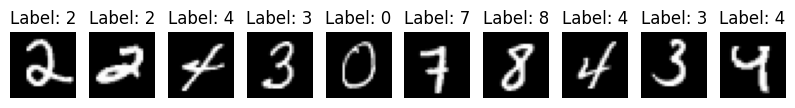

In [17]:
data.plot_random_samples(10)

In [23]:
SEED = 42

def get_network():
    net = Network()
    net.add(Dense(784, 10, ReLU(),    RandomNormal(0.01)))
    net.add(Dense(10,  10, Softmax(), RandomNormal(0.01)))
    return net

net = get_network()

def run_experiment(mode, **kwargs):
    np.random.seed(SEED)      # ← mismos pesos iniciales siempre
    net.reset_weights()
    np.random.seed()          # ← liberar seed para que el training sea aleatorio normal

    epochs = kwargs.pop("epochs", 200)      # o kwargs.get

    optimizer = SGD(learning_rate=0.05)
    model = Model(net, MeanSquaredError(), optimizer)
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        mode=mode,
        X_val=X_test,
        y_val=y_test,
        verbose=True,
        verbose_epoch=50,
        **kwargs
    )

    history.plot()
    model.evaluate(X_test, y_test)
    model.confusion_matrix(X_test, y_test)
    model.classification_report(X_test, y_test)

    return history

Epoch    1/200 [░░░░░░░░░░░░░░░░░░░░] loss=0.9000  acc=0.1144  ||g||=0.0636  |  val_loss=0.9000  val_acc=0.1401
Epoch   50/200 [█████░░░░░░░░░░░░░░░] loss=0.8918  acc=0.2513  ||g||=0.3542  |  val_loss=0.8910  val_acc=0.2526
Epoch  100/200 [██████████░░░░░░░░░░] loss=0.7525  acc=0.5079  ||g||=0.8577  |  val_loss=0.7464  val_acc=0.5090
Epoch  150/200 [███████████████░░░░░] loss=0.4520  acc=0.7457  ||g||=0.6015  |  val_loss=0.4415  val_acc=0.7567
Epoch  200/200 [████████████████████] loss=0.3232  acc=0.8075  ||g||=0.3612  |  val_loss=0.3147  val_acc=0.8170


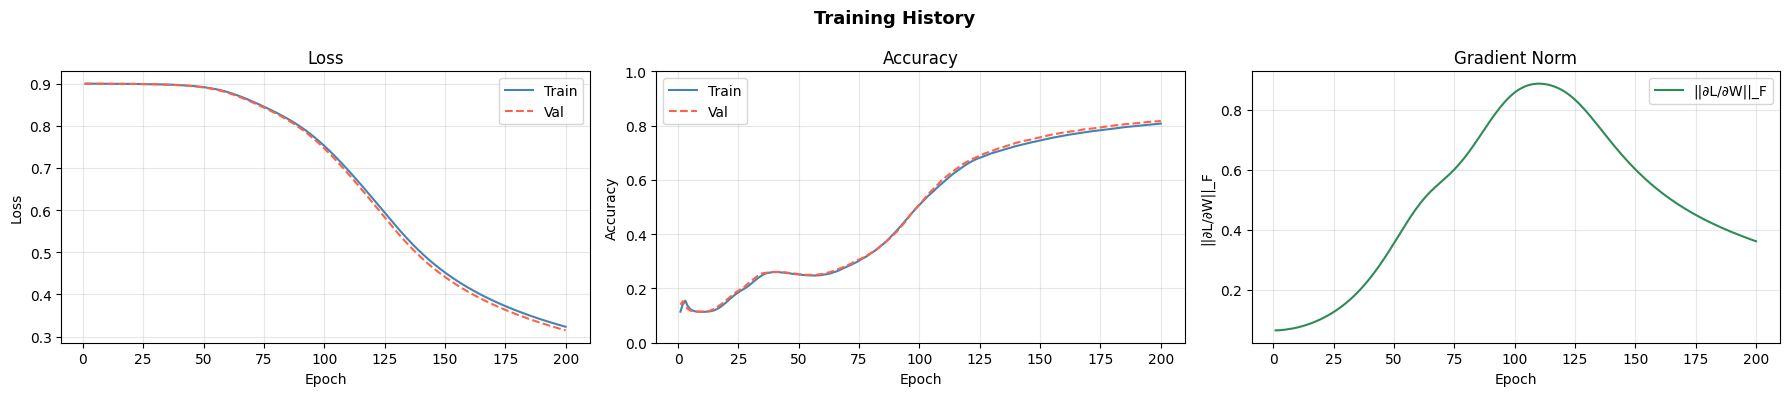

Loss: 0.3147  |  Accuracy: 0.8170 (81.70%)


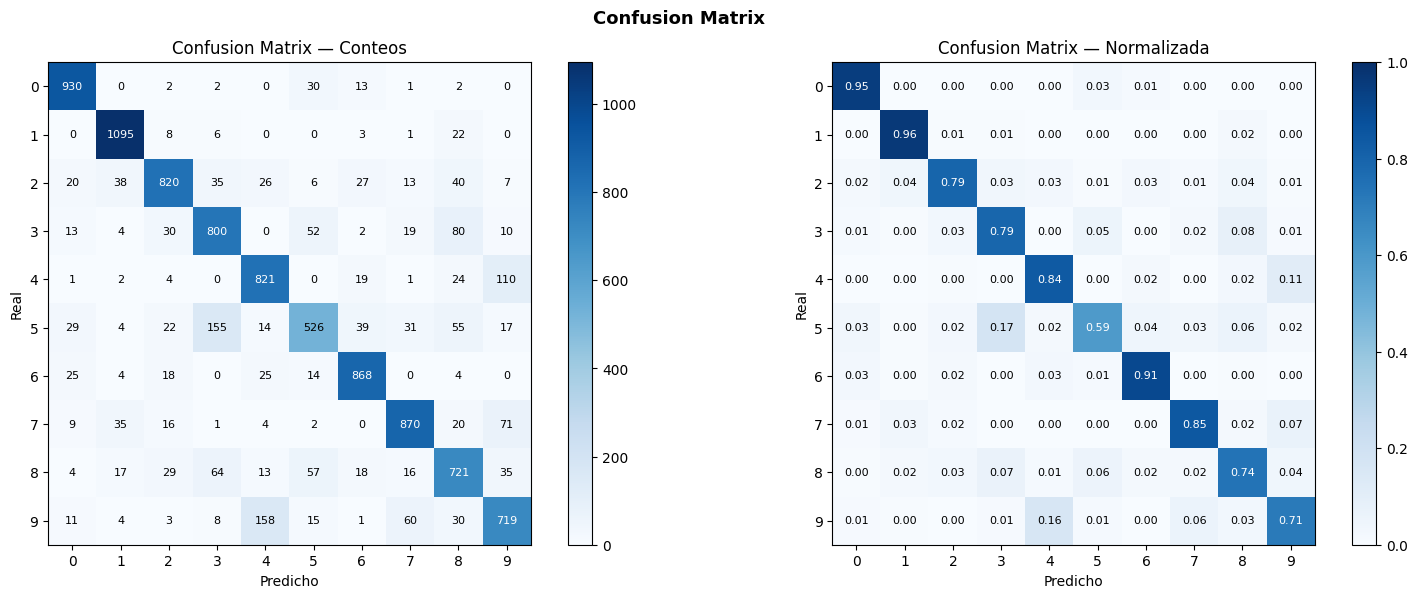


────────────────────────────────────────────────────
 Clase    Precision      Recall         F1      Samples 
────────────────────────────────────────────────────
   0        0.8925       0.9490       0.9199      980   
   1        0.9102       0.9648       0.9367      1135  
   2        0.8613       0.7946       0.8266      1032  
   3        0.7470       0.7921       0.7689      1010  
   4        0.7738       0.8360       0.8037      982   
   5        0.7493       0.5897       0.6600      892   
   6        0.8768       0.9061       0.8912      958   
   7        0.8597       0.8463       0.8529      1028  
   8        0.7224       0.7402       0.7312      974   
   9        0.7420       0.7126       0.7270      1009  
────────────────────────────────────────────────────
  avg       0.8135       0.8131       0.8118   
────────────────────────────────────────────────────



In [19]:
# Modo 1 — Batch GD completo
h_batch = run_experiment("full_batch")

Epoch    1/200 [░░░░░░░░░░░░░░░░░░░░] loss=0.9000  acc=0.1144  ||g||=0.0681  |  val_loss=0.9000  val_acc=0.1401
Epoch   50/200 [█████░░░░░░░░░░░░░░░] loss=0.8918  acc=0.2513  ||g||=0.3564  |  val_loss=0.8910  val_acc=0.2526
Epoch  100/200 [██████████░░░░░░░░░░] loss=0.7525  acc=0.5079  ||g||=0.8637  |  val_loss=0.7464  val_acc=0.5090
Epoch  150/200 [███████████████░░░░░] loss=0.4520  acc=0.7457  ||g||=0.6251  |  val_loss=0.4415  val_acc=0.7567
Epoch  200/200 [████████████████████] loss=0.3232  acc=0.8075  ||g||=0.3901  |  val_loss=0.3147  val_acc=0.8170


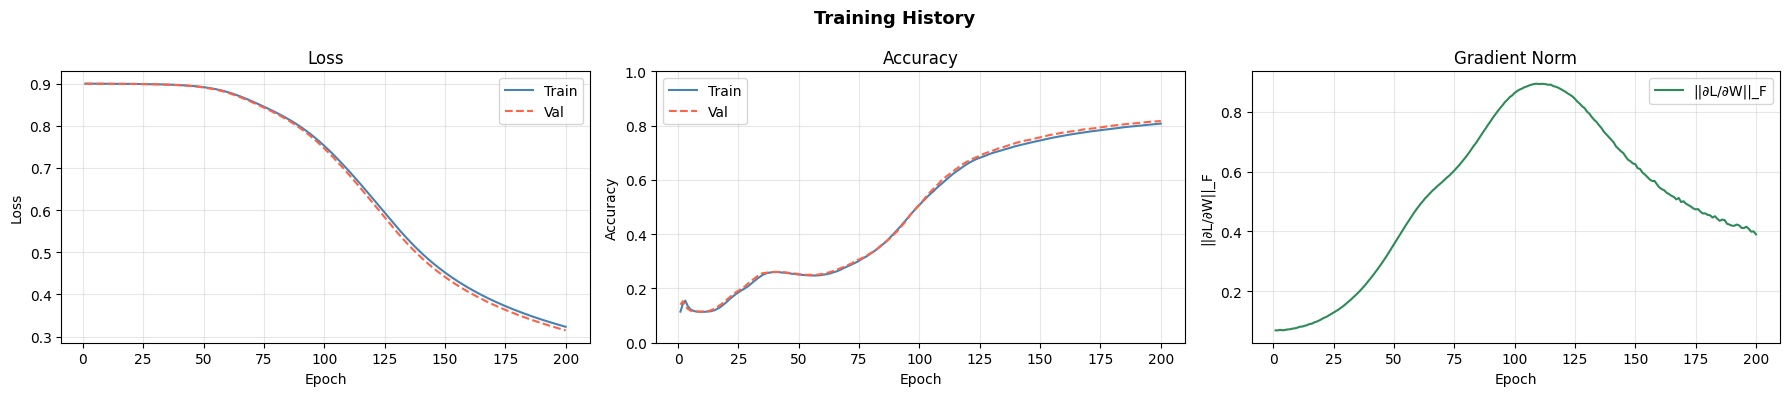

Loss: 0.3147  |  Accuracy: 0.8170 (81.70%)


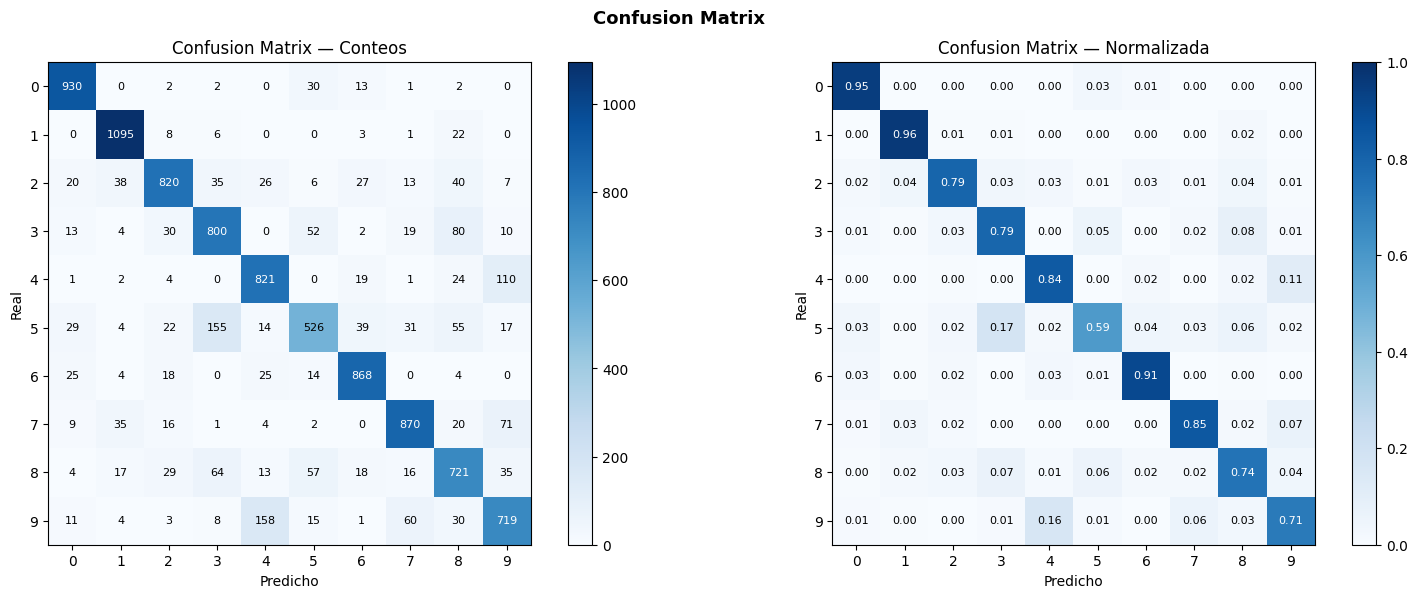


────────────────────────────────────────────────────
 Clase    Precision      Recall         F1      Samples 
────────────────────────────────────────────────────
   0        0.8925       0.9490       0.9199      980   
   1        0.9102       0.9648       0.9367      1135  
   2        0.8613       0.7946       0.8266      1032  
   3        0.7470       0.7921       0.7689      1010  
   4        0.7738       0.8360       0.8037      982   
   5        0.7493       0.5897       0.6600      892   
   6        0.8768       0.9061       0.8912      958   
   7        0.8597       0.8463       0.8529      1028  
   8        0.7224       0.7402       0.7312      974   
   9        0.7420       0.7126       0.7270      1009  
────────────────────────────────────────────────────
  avg       0.8135       0.8131       0.8118   
────────────────────────────────────────────────────



In [20]:
# Modo 2 — Promedio al final de época, W_new arranca siguiente época
h_batch_avg = run_experiment(
    "batch_avg_step",
    batch_size=6000,    # 10 batches de 6k
)


Epoch    1/1 [████████████████████] loss=0.3172  acc=0.8128  ||g||=4.5725  |  val_loss=0.3155  val_acc=0.8164


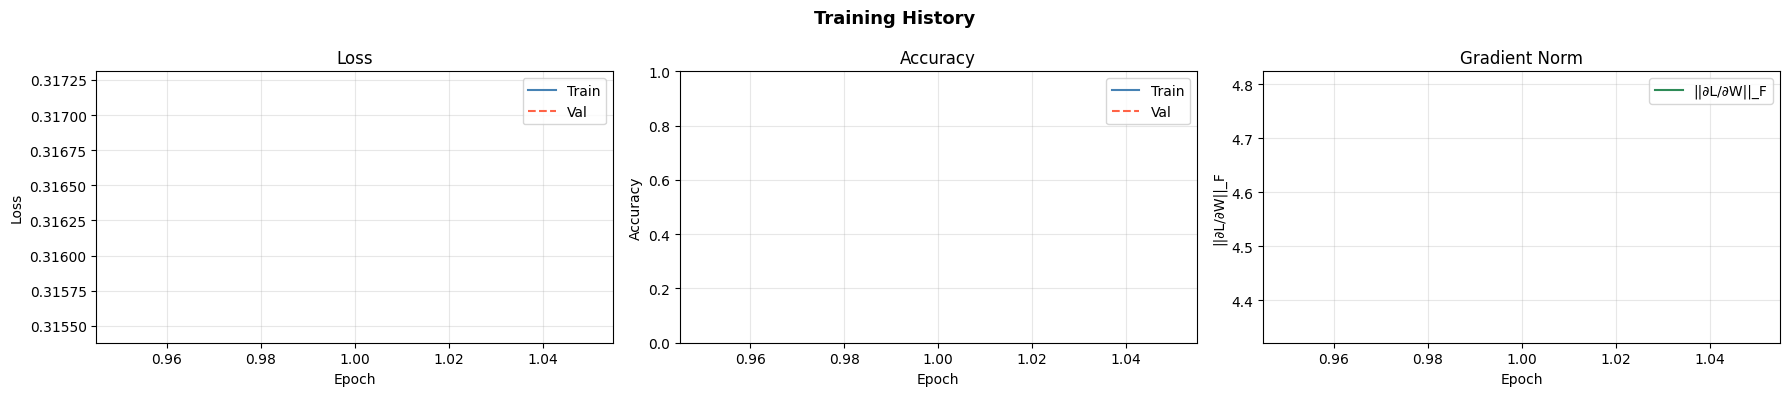

Loss: 0.3155  |  Accuracy: 0.8164 (81.64%)


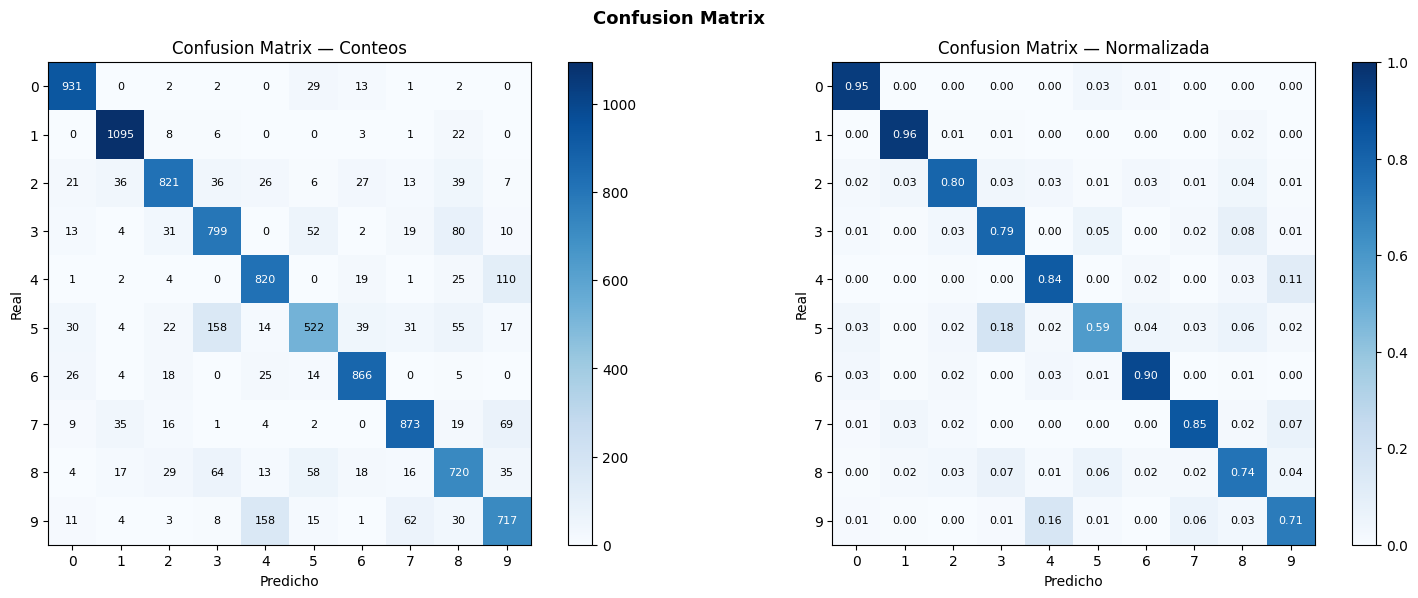


────────────────────────────────────────────────────
 Clase    Precision      Recall         F1      Samples 
────────────────────────────────────────────────────
   0        0.8901       0.9500       0.9191      980   
   1        0.9117       0.9648       0.9375      1135  
   2        0.8606       0.7955       0.8268      1032  
   3        0.7439       0.7911       0.7668      1010  
   4        0.7736       0.8350       0.8031      982   
   5        0.7479       0.5852       0.6566      892   
   6        0.8765       0.9040       0.8900      958   
   7        0.8584       0.8492       0.8538      1028  
   8        0.7222       0.7392       0.7306      974   
   9        0.7430       0.7106       0.7264      1009  
────────────────────────────────────────────────────
  avg       0.8128       0.8125       0.8111   
────────────────────────────────────────────────────



In [24]:
# Modo 3 — Workers disjuntos, promedio una sola vez al final
h_weight_avg = run_experiment(
    "weight_avg_step",
    epochs=1,
    n_workers=10,
    local_epochs=200,
)

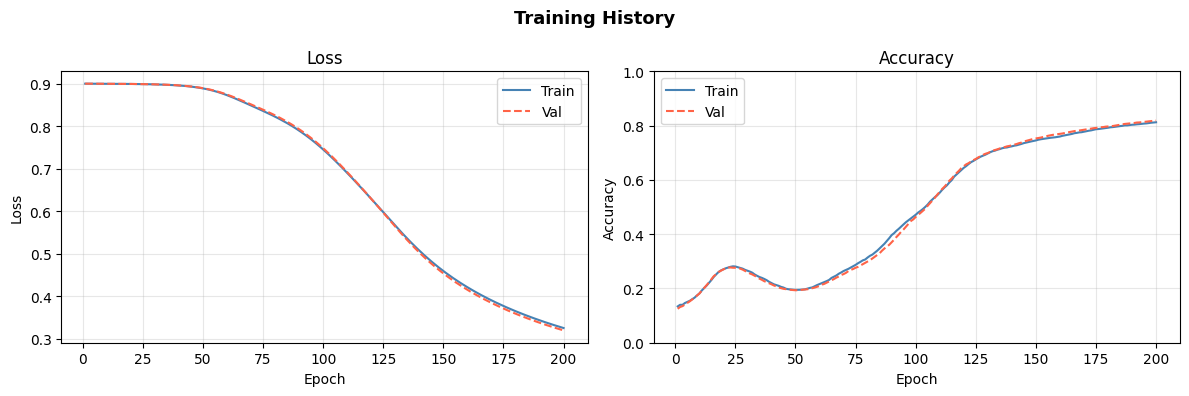

Loss: 0.3155  |  Accuracy: 0.8167 (81.67%)


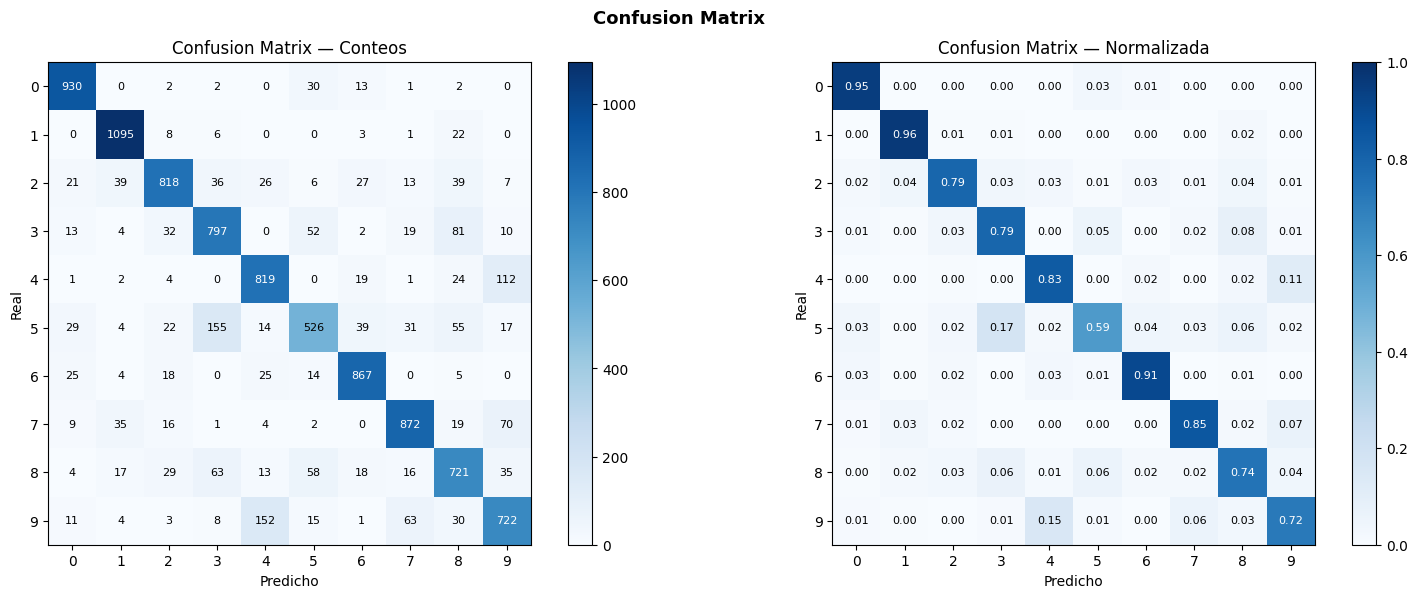


────────────────────────────────────────────────────
 Clase    Precision      Recall         F1      Samples 
────────────────────────────────────────────────────
   0        0.8917       0.9490       0.9194      980   
   1        0.9095       0.9648       0.9363      1135  
   2        0.8592       0.7926       0.8246      1032  
   3        0.7463       0.7891       0.7671      1010  
   4        0.7778       0.8340       0.8049      982   
   5        0.7482       0.5897       0.6596      892   
   6        0.8766       0.9050       0.8906      958   
   7        0.8574       0.8482       0.8528      1028  
   8        0.7224       0.7402       0.7312      974   
   9        0.7420       0.7156       0.7286      1009  
────────────────────────────────────────────────────
  avg       0.8131       0.8128       0.8115   
────────────────────────────────────────────────────



In [ ]:
def run_experiment_final_avg(n_workers=10, local_epochs=200, batch_size=None):
    np.random.seed(SEED)
    net.reset_weights()
    np.random.seed()
    model   = Model(net, MeanSquaredError(), SGD(learning_rate=0.05))

    history = model._final_avg_step(
        X_train, y_train,
        n_workers    = n_workers,
        local_epochs = local_epochs,
        batch_size   = batch_size,
        X_val        = X_test,
        y_val        = y_test,
    )

    history.plot()
    model.evaluate(X_test, y_test)
    model.confusion_matrix(X_test, y_test)
    model.classification_report(X_test, y_test)

    return history

h_final_avg = run_experiment_final_avg(n_workers=10, local_epochs=200)

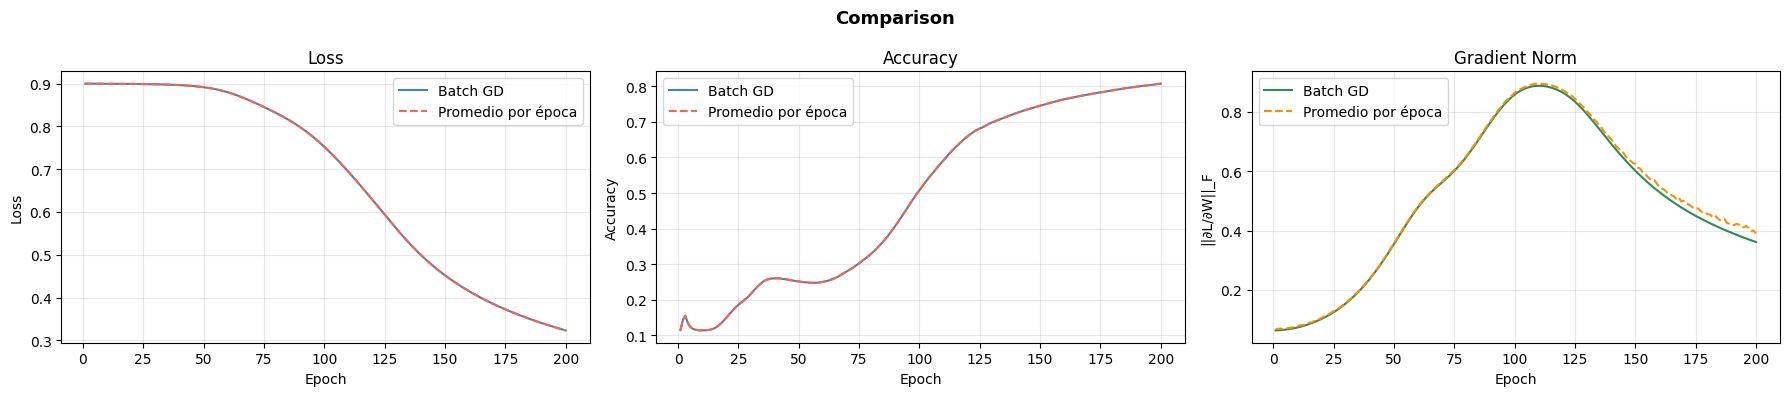

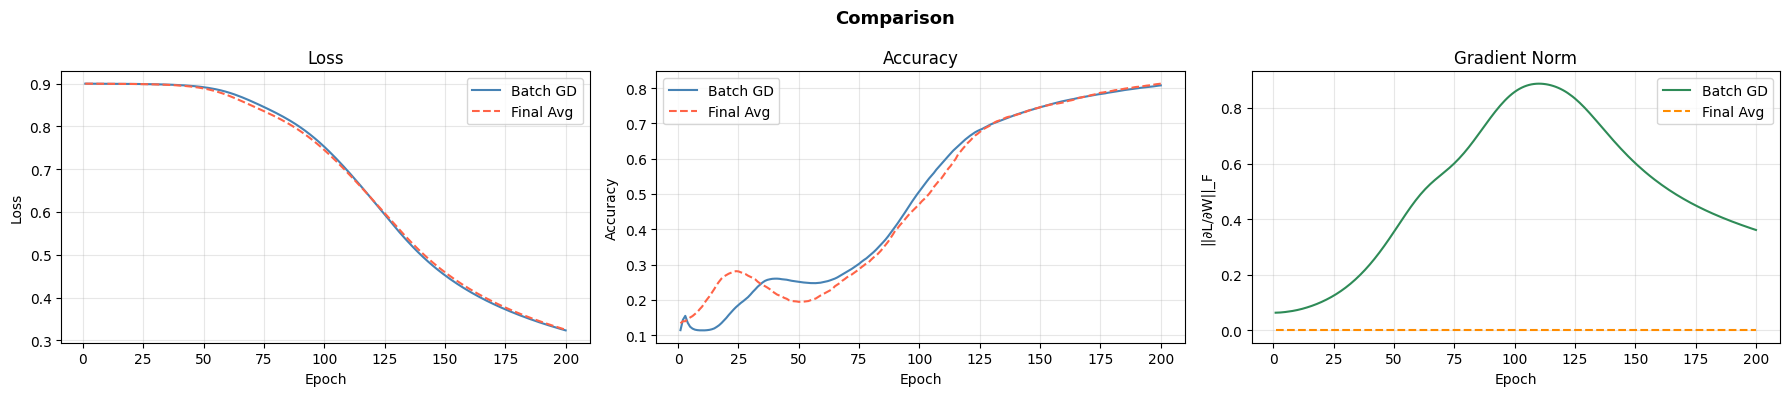

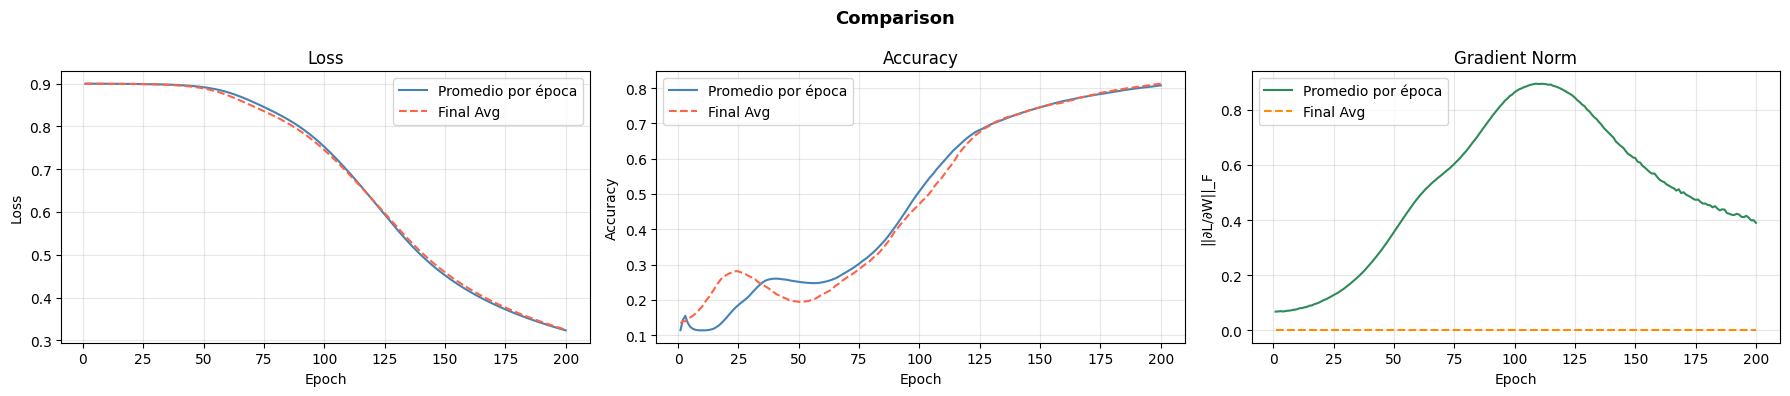

In [32]:
h_batch.plot_comparison(h_batch_avg,  "Batch GD", "Promedio por época")
h_batch.plot_comparison(h_final_avg,   "Batch GD", "Final Avg")

h_batch_avg.plot_comparison(h_final_avg, "Promedio por época", "Final Avg")


In [ ]:
# Ejecutar cada uno
h_batch      = run_experiment("batch")
h_minibatch  = run_experiment("minibatch",  batch_size=6000)
h_weight_avg = run_experiment("weight_avg", n_workers=10, local_epochs=1)
h_batch_avg  = run_experiment("batch_avg",  batch_size=6000)
h_grad_accum = run_experiment("grad_accum", batch_size=6000)
h_averaging  = run_experiment("averaging",  n_workers=10)

# Comparar visualmente
h_batch.plot_comparison(h_minibatch,  "Batch GD",    "Mini-batch")
h_batch.plot_comparison(h_weight_avg, "Batch GD",    "Weight Avg")
h_batch.plot_comparison(h_batch_avg,  "Batch GD",    "Batch Avg")
h_batch.plot_comparison(h_grad_accum, "Batch GD",    "Grad Accum")
h_batch.plot_comparison(h_averaging,  "Batch GD",    "Averaging")

In [ ]:


# Arquitectura
net = Network()
net.add(Dense(784, 256, Tanh(),    XavierUniform()))
net.add(Dropout(0.3))
net.add(Dense(256, 128, ReLU(),    HeNormal()))
net.add(Dropout(0.2))
net.add(Dense(128, 10,  Softmax(), XavierUniform()))
net.summary()

# Modelo
model = Model(net, CrossEntropy(), Adam(learning_rate=0.001))

# Entrenar — mini-batch
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    X_val=X_val,
    y_val=y_val,
)

history.plot()
model.evaluate(X_test, y_test)

# Comparar modo averaging
model2 = Model(net, CrossEntropy(), SGD(learning_rate=0.01))
history2 = model.fit(
    X_train, y_train,
    epochs=20,
    n_workers=4,       # averaging con 4 workers
    X_val=X_val,
    y_val=y_val,
)